Total NA events: 421
Cluster
0    158
1    182
2     81
Name: count, dtype: int64


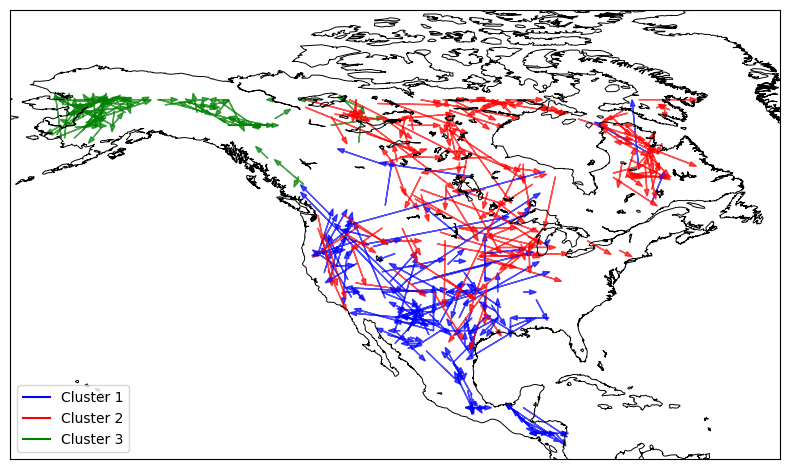

Clustered NA events saved to:
 D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# =========================
# PATHS
# =========================
in_file  = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_Summary_with_continent_dir4_8.xlsx"
out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx"

# =========================
# LOAD DATA
# =========================
df = pd.read_excel(in_file)

df.columns = df.columns.str.strip()

# =========================
# SUBSET TO NORTH AMERICA ONLY
# =========================
df_na = df[df["Continent"] == "North America"].copy()
print("Total NA events:", len(df_na))

# =========================
# BUILD FEATURES: spatial + direction
#   - Starting lat, lon
#   - Horizontal movement components (u east, v north)
#     from Distance + Bearing
# =========================

# Ensure numeric
for col in ["Starting Latitude", "Starting Longitude", "Ending Latitude",
            "Ending Longitude", "Distance", "Bearing"]:
    df_na[col] = pd.to_numeric(df_na[col], errors="coerce")

# Compute movement components in km
# Bearing is clockwise from north:
#   v (north) = D * cos(theta)
#   u (east)  = D * sin(theta)
theta = np.deg2rad(df_na["Bearing"].values)
D     = df_na["Distance"].values

u_east  = D * np.sin(theta)   # +ve eastward, -ve westward
v_north = D * np.cos(theta)   # +ve northward, -ve southward

df_na["u_east_km"]  = u_east
df_na["v_north_km"] = v_north

# Feature matrix: location + vector
feature_cols = ["Starting Latitude", "Starting Longitude",
                "u_east_km", "v_north_km"]
X = df_na[feature_cols].values

# =========================
# STANDARDIZE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# K-MEANS CLUSTERING
# =========================
n_clusters = 3 
kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
df_na["Cluster"] = kmeans.fit_predict(X_scaled)

print(df_na["Cluster"].value_counts().sort_index())

# =========================
# PLOT ON MAP
# =========================
colors = {0: "blue", 1:"red" , 2: "green", 3: "orange", 4: "purple"}

plt.figure(figsize=(8, 6))
m = Basemap(
    projection="cyl",
    llcrnrlon=-170, urcrnrlon=-50,
    llcrnrlat=10,   urcrnrlat=80,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)

for _, row in df_na.iterrows():
    slat = row["Starting Latitude"]
    slon = row["Starting Longitude"]
    elat = row["Ending Latitude"]
    elon = row["Ending Longitude"]
    c    = int(row["Cluster"])

    col = colors[c]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    # straight arrow from start to end
    plt.arrow(xs, ys, xe - xs, ye - ys,
              color=col, alpha=0.7, linewidth=1,
              head_width=0.7)

# legend
for c in range(n_clusters):
    plt.plot([], [], color=colors[c], label=f"Cluster {c+1}")

plt.legend(loc="lower left")

plt.tight_layout()


plt.savefig(r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\NA-1.png",
            dpi=300, transparent=True, bbox_inches='tight')

plt.show()

# =========================
# SAVE CLUSTERED TABLE
# =========================
df_na.to_excel(out_file, index=False)
print("Clustered NA events saved to:\n", out_file)

Total events in file: 2477
Total North America events: 421
North America events after removing missing values: 421

Cluster validation metrics:
   K      Inertia  Silhouette_Score  Calinski_Harabasz_Score  \
0  2  1288.155293          0.274449               128.756939   
1  3   986.371429          0.292184               147.818932   
2  4   835.680269          0.310794               141.102341   
3  5   735.371697          0.312376               134.159832   
4  6   642.733619          0.318557               134.464896   
5  7   574.126862          0.333561               133.387325   
6  8   527.062179          0.301377               129.509068   

   Davies_Bouldin_Score  
0              1.164364  
1              1.294088  
2              1.248455  
3              1.255650  
4              1.151442  
5              1.077793  
6              1.098125  

Validation metrics saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\KMeans_Cluster_Va

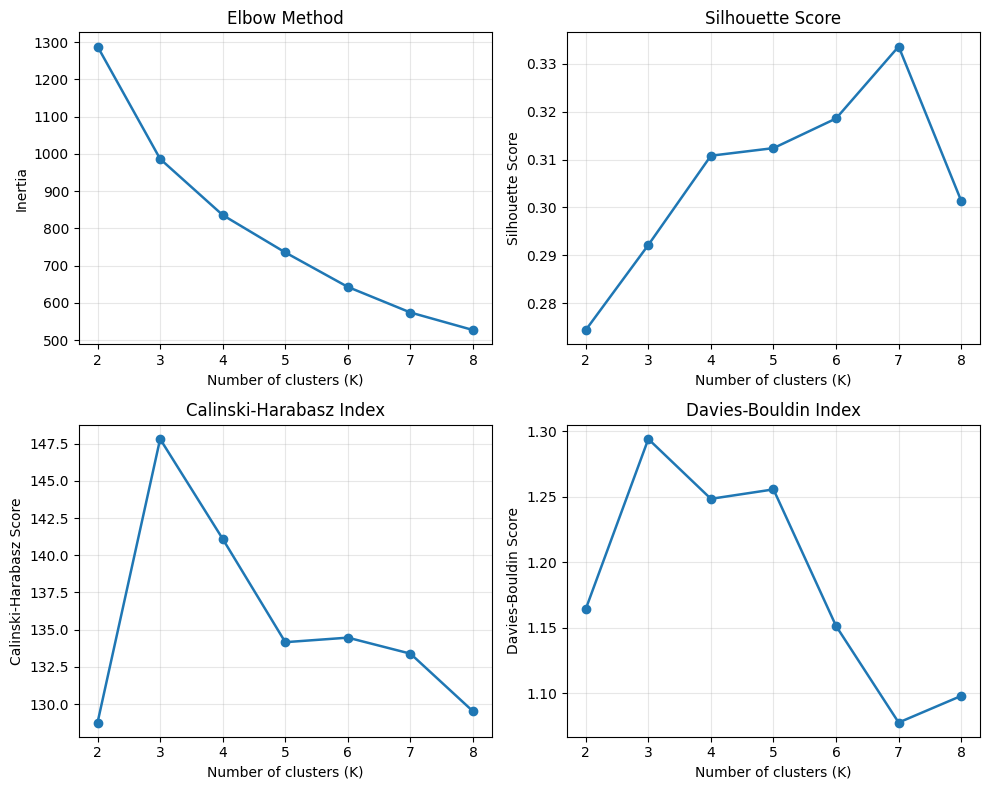


Validation plot saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\KMeans_Cluster_Validation.png

Final cluster counts:
Cluster_Label
1    158
2    182
3     81
Name: count, dtype: int64

Clustered North America events saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx


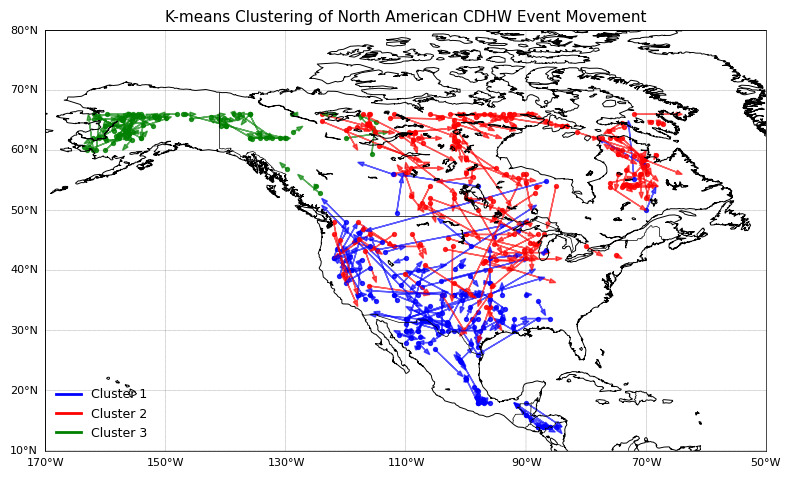


Final cluster map saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots\NA_DirSpace_KMeans_Clusters_K3.png


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from mpl_toolkits.basemap import Basemap


# ============================================================
# PATHS
# ============================================================

in_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_Summary_with_continent_dir4_8.xlsx"

out_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx"

plot_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\Plots"
os.makedirs(plot_dir, exist_ok=True)

validation_metrics_file = os.path.join(
    plot_dir,
    "KMeans_Cluster_Validation_Metrics.xlsx"
)

validation_plot_file = os.path.join(
    plot_dir,
    "KMeans_Cluster_Validation.png"
)

map_plot_file = os.path.join(
    plot_dir,
    "NA_DirSpace_KMeans_Clusters_K3.png"
)


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel(in_file)

# Clean column names
df.columns = df.columns.str.strip()

print("Total events in file:", len(df))


# ============================================================
# SUBSET TO NORTH AMERICA ONLY
# ============================================================

df_na = df[df["Continent"] == "North America"].copy()

print("Total North America events:", len(df_na))


# ============================================================
# MAKE REQUIRED COLUMNS NUMERIC
# ============================================================

required_cols = [
    "Starting Latitude",
    "Starting Longitude",
    "Ending Latitude",
    "Ending Longitude",
    "Distance",
    "Bearing"
]

for col in required_cols:
    df_na[col] = pd.to_numeric(df_na[col], errors="coerce")


# ============================================================
# COMPUTE MOVEMENT COMPONENTS
# Bearing is clockwise from north:
#   u_east  = Distance * sin(theta)
#   v_north = Distance * cos(theta)
# ============================================================

theta = np.deg2rad(df_na["Bearing"])
D = df_na["Distance"]

df_na["u_east_km"] = D * np.sin(theta)
df_na["v_north_km"] = D * np.cos(theta)


# ============================================================
# BUILD FEATURE MATRIX
# Location + movement direction/magnitude
# ============================================================

feature_cols = [
    "Starting Latitude",
    "Starting Longitude",
    "u_east_km",
    "v_north_km"
]

# Drop rows with missing feature values
df_na = df_na.dropna(subset=feature_cols).copy()

print("North America events after removing missing values:", len(df_na))

X = df_na[feature_cols].values


# ============================================================
# STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# CLUSTER VALIDATION FOR K = 2 TO 8
# ============================================================

K_range = range(2, 9)

inertia_list = []
silhouette_list = []
calinski_list = []
davies_list = []

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        n_init=50,
        random_state=42
    )

    labels_temp = kmeans_temp.fit_predict(X_scaled)

    inertia_list.append(kmeans_temp.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels_temp))
    calinski_list.append(calinski_harabasz_score(X_scaled, labels_temp))
    davies_list.append(davies_bouldin_score(X_scaled, labels_temp))


cluster_metrics = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia_list,
    "Silhouette_Score": silhouette_list,
    "Calinski_Harabasz_Score": calinski_list,
    "Davies_Bouldin_Score": davies_list
})

print("\nCluster validation metrics:")
print(cluster_metrics)

cluster_metrics.to_excel(validation_metrics_file, index=False)

print("\nValidation metrics saved to:")
print(validation_metrics_file)


# ============================================================
# PLOT CLUSTER VALIDATION METRICS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Elbow method
axes[0, 0].plot(
    cluster_metrics["K"],
    cluster_metrics["Inertia"],
    marker="o",
    linewidth=1.8
)
axes[0, 0].set_xlabel("Number of clusters (K)")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_title("Elbow Method")
axes[0, 0].grid(alpha=0.3)

# Silhouette score
axes[0, 1].plot(
    cluster_metrics["K"],
    cluster_metrics["Silhouette_Score"],
    marker="o",
    linewidth=1.8
)
axes[0, 1].set_xlabel("Number of clusters (K)")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].grid(alpha=0.3)

# Calinski-Harabasz score
axes[1, 0].plot(
    cluster_metrics["K"],
    cluster_metrics["Calinski_Harabasz_Score"],
    marker="o",
    linewidth=1.8
)
axes[1, 0].set_xlabel("Number of clusters (K)")
axes[1, 0].set_ylabel("Calinski-Harabasz Score")
axes[1, 0].set_title("Calinski-Harabasz Index")
axes[1, 0].grid(alpha=0.3)

# Davies-Bouldin score
axes[1, 1].plot(
    cluster_metrics["K"],
    cluster_metrics["Davies_Bouldin_Score"],
    marker="o",
    linewidth=1.8
)
axes[1, 1].set_xlabel("Number of clusters (K)")
axes[1, 1].set_ylabel("Davies-Bouldin Score")
axes[1, 1].set_title("Davies-Bouldin Index")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    validation_plot_file,
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

print("\nValidation plot saved to:")
print(validation_plot_file)


# ============================================================
# FINAL K-MEANS CLUSTERING
# Selected K = 3 based on balance between validation metrics
# and physical interpretability
# ============================================================

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    n_init=50,
    random_state=42
)

df_na["Cluster"] = kmeans.fit_predict(X_scaled)

# Make cluster labels start from 1 instead of 0
df_na["Cluster_Label"] = df_na["Cluster"] + 1

print("\nFinal cluster counts:")
print(df_na["Cluster_Label"].value_counts().sort_index())


# ============================================================
# SAVE CLUSTERED TABLE
# ============================================================

df_na.to_excel(out_file, index=False)

print("\nClustered North America events saved to:")
print(out_file)


# ============================================================
# PLOT FINAL CLUSTERS ON MAP
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green",
    3: "orange",
    4: "purple",
    5: "brown",
    6: "magenta",
    7: "cyan"
}

plt.figure(figsize=(8, 6))

m = Basemap(
    projection="cyl",
    llcrnrlon=-170,
    urcrnrlon=-50,
    llcrnrlat=10,
    urcrnrlat=80,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)
m.drawcountries(linewidth=0.5)
m.drawmapboundary(linewidth=0.5)

# Optional: draw parallels and meridians
m.drawparallels(
    np.arange(10, 81, 10),
    labels=[1, 0, 0, 0],
    linewidth=0.2,
    fontsize=8
)

m.drawmeridians(
    np.arange(-170, -49, 20),
    labels=[0, 0, 0, 1],
    linewidth=0.2,
    fontsize=8
)

for _, row in df_na.iterrows():

    slat = row["Starting Latitude"]
    slon = row["Starting Longitude"]
    elat = row["Ending Latitude"]
    elon = row["Ending Longitude"]
    c = int(row["Cluster"])

    col = colors[c]

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    # Arrow from start to end
    plt.arrow(
        xs,
        ys,
        xe - xs,
        ye - ys,
        color=col,
        alpha=0.65,
        linewidth=1.0,
        head_width=0.7,
        head_length=1.0,
        length_includes_head=True
    )

    # Optional: starting point
    plt.scatter(
        xs,
        ys,
        s=8,
        color=col,
        alpha=0.8
    )


# Legend
for c in range(n_clusters):
    plt.plot(
        [],
        [],
        color=colors[c],
        linewidth=2,
        label=f"Cluster {c + 1}"
    )

plt.legend(
    loc="lower left",
    frameon=False,
    fontsize=9
)

plt.title(
    "K-means Clustering of North American CDHW Event Movement",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    map_plot_file,
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

print("\nFinal cluster map saved to:")
print(map_plot_file)

Total events in cluster 1: 182
Kept with directions SE or E: 89


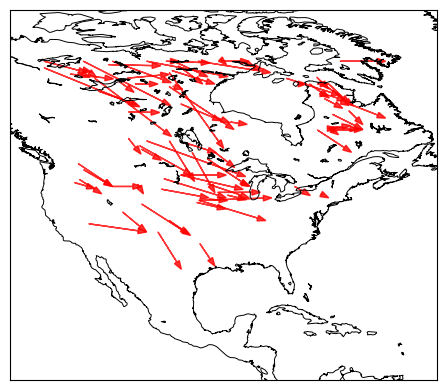

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# ======== LOAD FILE ========
file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Event_Displacement_NA_DirSpace_Clusters.xlsx"
df = pd.read_excel(file)

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Direction column (4- or 8-bin)
direction_col = "direction8" if "direction8" in df.columns else "direction4"

# ======== FILTER: CLUSTER + DIRECTIONS (SE and E) ========
# keep only cluster 1
df = df[df["cluster"] == 1].copy()

wanted_dirs = ["SE", "E"]

# make sure direction strings are clean
df[direction_col] = df[direction_col].astype(str).str.strip().str.upper()

# keep only rows where direction is SE or E
df_keep = df[df[direction_col].isin(wanted_dirs)].copy()

print("Total events in cluster 1:", len(df))
print("Kept with directions SE or E:", len(df_keep))

# ======== PLOT ========
plt.figure(figsize=(6, 4))

m = Basemap(
    projection="cyl",
    llcrnrlon=-130, urcrnrlon=-55,
    llcrnrlat=10,   urcrnrlat=75,
    resolution="l"
)

m.drawcoastlines(linewidth=0.7)

# Colors by direction, not by cluster
dir_colors = {
    "SE": "red",
    "E":  "red"
}

for _, row in df_keep.iterrows():
    slon = row["starting longitude"]
    slat = row["starting latitude"]
    elon = row["ending longitude"]
    elat = row["ending latitude"]
    ddir = row[direction_col]   # SE or E

    xs, ys = m(slon, slat)
    xe, ye = m(elon, elat)

    plt.arrow(xs, ys, xe - xs, ye - ys,
              length_includes_head=True,
              head_width=1.0,
              head_length=1.5,
              color=dir_colors.get(ddir, "k"),
              alpha=0.8)

plt.tight_layout()

plt.savefig(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\NA_SE_vs_E.png",
    dpi=300, transparent=True, bbox_inches='tight'
)

plt.show()


In [55]:
import os
import pandas as pd


# ============================================================
# INPUT FILE
# ============================================================

file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America"
    r"\Event_Displacement_NA_DirSpace_Clusters.xlsx"
)


# ============================================================
# OUTPUT FILE
# ============================================================

out_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America"
    r"\Cluster1_SE_E_89events.xlsx"
)


# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(file)

# Clean column names
df.columns = [
    c.strip().lower()
    for c in df.columns
]


# ============================================================
# FIND DIRECTION COLUMN
# ============================================================

if "direction8" in df.columns:
    direction_col = "direction8"

elif "direction4" in df.columns:
    direction_col = "direction4"

else:
    raise ValueError(
        "Neither direction8 nor direction4 column exists."
    )


# ============================================================
# CLEAN DIRECTION VALUES
# ============================================================

df[direction_col] = (
    df[direction_col]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# KEEP ONLY CLUSTER 1
# ============================================================

cluster1 = df[
    df["cluster"] == 1
].copy()


# ============================================================
# KEEP ONLY SE + E EVENTS
# ============================================================

wanted_dirs = [
    "SE",
    "E"
]

df_keep = cluster1[
    cluster1[direction_col].isin(wanted_dirs)
].copy()


# ============================================================
# PRINT COUNTS
# ============================================================

print(
    "Total events in original file:",
    len(df)
)

print(
    "Total events in Cluster 1:",
    len(cluster1)
)

print(
    "Cluster 1 events with E or SE direction:",
    len(df_keep)
)

print("\nDirection counts:")

print(
    df_keep[direction_col]
    .value_counts()
)


# ============================================================
# SAVE THE FILTERED EVENTS
# ============================================================

df_keep.to_excel(
    out_file,
    index=False
)


# ============================================================
# DONE
# ============================================================

print("\nSaved filtered Excel file:")
print(out_file)

Total events in original file: 421
Total events in Cluster 1: 182
Cluster 1 events with E or SE direction: 89

Direction counts:
direction8
SE    54
E     35
Name: count, dtype: int64

Saved filtered Excel file:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Cluster1_SE_E_89events.xlsx


Total Cluster 1 events: 182
Kept after SE direction filter: 54

Excel saved:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Cluster1_SE_54_events.xlsx

Plot saved:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Cluster1_SE_54_events.png


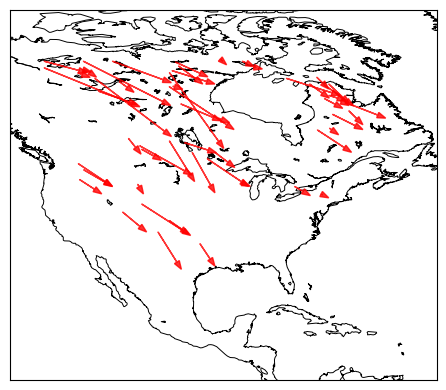


FINAL NUMBER OF EVENTS: 54


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os

# ============================================================
# 1. LOAD EVENT MIGRATION FILE
# ============================================================

file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\Event_Displacement_NA_DirSpace_Clusters.xlsx"
)

# New output folder
out_folder = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\step-10 _Migration_usa"
)

os.makedirs(out_folder, exist_ok=True)

# Output Excel
out_excel = os.path.join(
    out_folder,
    "Cluster1_SE_54_events.xlsx"
)

# Output plot
out_plot = os.path.join(
    out_folder,
    "Cluster1_SE_54_events.png"
)

# ============================================================
# 2. READ DATA
# ============================================================

df = pd.read_excel(file)

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Direction column
direction_col = (
    "direction8"
    if "direction8" in df.columns
    else "direction4"
)

# ============================================================
# 3. CLUSTER + DIRECTION FILTER
# ============================================================

cluster_dir_map = {
    1: "SE"
}

df = df[
    df["cluster"].isin(
        cluster_dir_map.keys()
    )
].copy()

df["keep_flag"] = df.apply(
    lambda r:
    str(r[direction_col]).strip().upper()
    ==
    cluster_dir_map[r["cluster"]],
    axis=1
)

df_keep = df[
    df["keep_flag"]
].copy()

# Reset index
df_keep = df_keep.reset_index(drop=True)

print("Total Cluster 1 events:", len(df))
print(
    "Kept after SE direction filter:",
    len(df_keep)
)

# ============================================================
# 4. SAVE 54 EVENTS TO EXCEL
# ============================================================

# Remove temporary filtering column before saving
df_save = df_keep.drop(
    columns=["keep_flag"],
    errors="ignore"
)

df_save.to_excel(
    out_excel,
    index=False
)

print("\nExcel saved:")
print(out_excel)

# ============================================================
# 5. SETUP BASEMAP PLOT
#    ORIGINAL STYLE
# ============================================================

plt.figure(
    figsize=(6, 4)
)

m = Basemap(
    projection="cyl",
    llcrnrlon=-130,
    urcrnrlon=-55,
    llcrnrlat=10,
    urcrnrlat=75,
    resolution="l"
)

m.drawcoastlines(
    linewidth=0.7
)

# ============================================================
# 6. EVENT MIGRATION ARROWS
#    ORIGINAL RED-ARROW STYLE
# ============================================================

for _, row in df_keep.iterrows():

    slon = row[
        "starting longitude"
    ]

    slat = row[
        "starting latitude"
    ]

    elon = row[
        "ending longitude"
    ]

    elat = row[
        "ending latitude"
    ]

    xs, ys = m(
        slon,
        slat
    )

    xe, ye = m(
        elon,
        elat
    )

    plt.arrow(
        xs,
        ys,
        xe - xs,
        ye - ys,
        length_includes_head=True,
        head_width=1.0,
        head_length=1.5,
        color="red",
        alpha=0.8,
        zorder=15
    )

# ============================================================
# 7. SAVE & SHOW
# ============================================================

plt.tight_layout()

plt.savefig(
    out_plot,
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

print("\nPlot saved:")
print(out_plot)

plt.show()

# ============================================================
# 8. FINAL CHECK
# ============================================================

print("\n===================================")
print("FINAL NUMBER OF EVENTS:", len(df_keep))
print("===================================")

Number of events: 54

90% density threshold: 0.0008363725217514497
Number of 90% polygons: 7


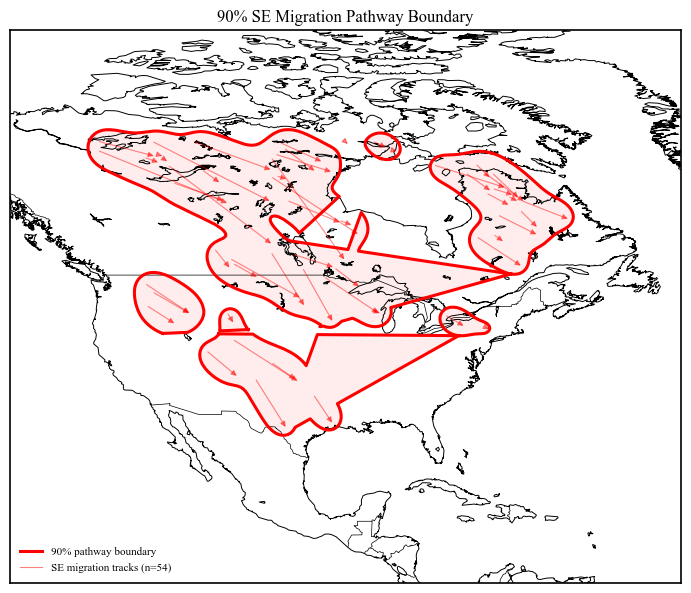


DONE

Events: 54

90% boundary figure:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Gaussian_90pct_Boundary\SE54_90pct_Gaussian_Boundary.png

90% Shapefile:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Gaussian_90pct_Boundary\SE54_90pct_Gaussian_Boundary.shp

90% GeoPackage:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Gaussian_90pct_Boundary\SE54_90pct_Gaussian_Boundary.gpkg


In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from scipy.ndimage import gaussian_filter
from shapely.geometry import Polygon, MultiPolygon
from mpl_toolkits.basemap import Basemap


# ============================================================
# INPUT: 54 SE EVENTS
# ============================================================

file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\step-10 _Migration_usa"
    r"\Cluster1_SE_54_events.xlsx"
)


# ============================================================
# OUTPUT
# ============================================================

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\step-10 _Migration_usa"
    r"\Gaussian_90pct_Boundary"
)

os.makedirs(out_dir, exist_ok=True)


# ============================================================
# SETTINGS
# ============================================================

lon_min = -135
lon_max = -50

lat_min = 10
lat_max = 80

grid_res = 0.3

n_interp = 150

# Increase this if boundary is fragmented
sigma = 5.0

# ONLY 90%
probability = 0.90


# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(file)

df.columns = [
    c.strip().lower()
    for c in df.columns
]


required_cols = [
    "starting longitude",
    "starting latitude",
    "ending longitude",
    "ending latitude"
]


for col in required_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=required_cols
).copy()


print("Number of events:", len(df))


# ============================================================
# LONGITUDE CONVERSION
# ============================================================

def lon180(lon):

    lon = float(lon)

    if lon > 180:
        lon -= 360

    return lon


df["start_lon"] = (
    df["starting longitude"]
    .apply(lon180)
)

df["end_lon"] = (
    df["ending longitude"]
    .apply(lon180)
)

df["start_lat"] = (
    df["starting latitude"]
)

df["end_lat"] = (
    df["ending latitude"]
)


# ============================================================
# CREATE GRID
# ============================================================

lon_edges = np.arange(
    lon_min,
    lon_max + grid_res,
    grid_res
)

lat_edges = np.arange(
    lat_min,
    lat_max + grid_res,
    grid_res
)


lon_centers = (
    lon_edges[:-1]
    + lon_edges[1:]
) / 2

lat_centers = (
    lat_edges[:-1]
    + lat_edges[1:]
) / 2


density = np.zeros(
    (
        len(lat_centers),
        len(lon_centers)
    ),
    dtype=float
)


# ============================================================
# PUT EACH TRAJECTORY ON GRID
# ============================================================

for _, row in df.iterrows():

    slon = row["start_lon"]
    slat = row["start_lat"]

    elon = row["end_lon"]
    elat = row["end_lat"]


    lons = np.linspace(
        slon,
        elon,
        n_interp
    )

    lats = np.linspace(
        slat,
        elat,
        n_interp
    )


    lon_idx = np.floor(
        (lons - lon_min)
        / grid_res
    ).astype(int)


    lat_idx = np.floor(
        (lats - lat_min)
        / grid_res
    ).astype(int)


    valid = (
        (lon_idx >= 0)
        &
        (lon_idx < density.shape[1])
        &
        (lat_idx >= 0)
        &
        (lat_idx < density.shape[0])
    )


    lon_idx = lon_idx[valid]
    lat_idx = lat_idx[valid]


    # One event counted once per grid cell
    cells = np.unique(
        np.column_stack(
            [
                lat_idx,
                lon_idx
            ]
        ),
        axis=0
    )


    for lat_i, lon_i in cells:

        density[
            lat_i,
            lon_i
        ] += 1


# ============================================================
# NORMALIZE
# ============================================================

density = (
    density
    / len(df)
)


# ============================================================
# GAUSSIAN SMOOTHING
# ============================================================

density_smooth = gaussian_filter(
    density,
    sigma=sigma
)


# ============================================================
# FIND 90% CUMULATIVE-DENSITY THRESHOLD
# ============================================================

values = density_smooth[
    density_smooth > 0
]


values_sorted = np.sort(
    values
)[::-1]


cumulative = np.cumsum(
    values_sorted
)

cumulative = (
    cumulative
    / cumulative[-1]
)


idx = np.searchsorted(
    cumulative,
    probability
)


threshold_90 = (
    values_sorted[idx]
)


print(
    "\n90% density threshold:",
    threshold_90
)


# ============================================================
# GRID MESH
# ============================================================

LON, LAT = np.meshgrid(
    lon_centers,
    lat_centers
)


# ============================================================
# EXTRACT 90% CONTOUR
# ============================================================

fig_temp, ax_temp = plt.subplots()


cs = ax_temp.contour(
    LON,
    LAT,
    density_smooth,
    levels=[
        threshold_90
    ]
)


polygons = []


for path in cs.get_paths():

    vertices = (
        path.vertices
    )

    if len(vertices) < 4:
        continue


    poly = Polygon(
        vertices
    )


    if not poly.is_valid:
        poly = poly.buffer(0)


    if poly.is_empty:
        continue


    if isinstance(
        poly,
        Polygon
    ):

        polygons.append(
            poly
        )


    elif isinstance(
        poly,
        MultiPolygon
    ):

        polygons.extend(
            list(
                poly.geoms
            )
        )


plt.close(
    fig_temp
)


# ============================================================
# REMOVE VERY SMALL ISOLATED POLYGONS
# ============================================================

polygons = [
    p
    for p in polygons
    if p.area > 0.5
]


print(
    "Number of 90% polygons:",
    len(polygons)
)


# ============================================================
# GEODATAFRAME
# ============================================================

gdf90 = gpd.GeoDataFrame(

    {
        "level": [
            90
        ] * len(polygons)
    },

    geometry=polygons,

    crs="EPSG:4326"
)


# ============================================================
# SAVE 90% BOUNDARY
# ============================================================

shp_out = os.path.join(
    out_dir,
    "SE54_90pct_Gaussian_Boundary.shp"
)


gpkg_out = os.path.join(
    out_dir,
    "SE54_90pct_Gaussian_Boundary.gpkg"
)


gdf90.to_file(
    shp_out
)


gdf90.to_file(
    gpkg_out,
    driver="GPKG"
)


# ============================================================
# FINAL MAP
# ============================================================

fig = plt.figure(
    figsize=(8, 6)
)

ax = plt.gca()


m = Basemap(

    projection="cyl",

    llcrnrlon=lon_min,
    urcrnrlon=lon_max,

    llcrnrlat=lat_min,
    urcrnrlat=lat_max,

    resolution="l",

    ax=ax
)


m.drawcoastlines(
    linewidth=0.7,
    color="black"
)

m.drawcountries(
    linewidth=0.5,
    color="black"
)


# ============================================================
# 90% BOUNDARY + LIGHT FILL
# ============================================================

for geom in gdf90.geometry:

    x, y = geom.exterior.xy


    # light interior
    ax.fill(
        x,
        y,
        color="red",
        alpha=0.07,
        zorder=1
    )


    # strong 90% boundary
    ax.plot(
        x,
        y,
        color="red",
        linewidth=2.2,
        alpha=1.0,
        zorder=3
    )


# ============================================================
# ORIGINAL 54 ARROWS
# ============================================================

for _, row in df.iterrows():

    ax.annotate(

        "",

        xy=(
            row["end_lon"],
            row["end_lat"]
        ),

        xytext=(
            row["start_lon"],
            row["start_lat"]
        ),

        arrowprops=dict(

            arrowstyle="-|>",

            color="red",

            linewidth=0.85,

            alpha=0.45,

            mutation_scale=8
        ),

        zorder=4
    )


# ============================================================
# LEGEND
# ============================================================

ax.plot(
    [],
    [],
    color="red",
    linewidth=2.2,
    label="90% pathway boundary"
)

ax.plot(
    [],
    [],
    color="red",
    linewidth=0.8,
    alpha=0.5,
    label=f"SE migration tracks (n={len(df)})"
)


ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=8
)


ax.set_title(
    "90% SE Migration Pathway Boundary",
    fontsize=12
)


plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

fig_out = os.path.join(
    out_dir,
    "SE54_90pct_Gaussian_Boundary.png"
)


plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ============================================================
# PRINT OUTPUT
# ============================================================

print("\n==============================")
print("DONE")
print("==============================")

print("\nEvents:", len(df))

print("\n90% boundary figure:")
print(fig_out)

print("\n90% Shapefile:")
print(shp_out)

print("\n90% GeoPackage:")
print(gpkg_out)

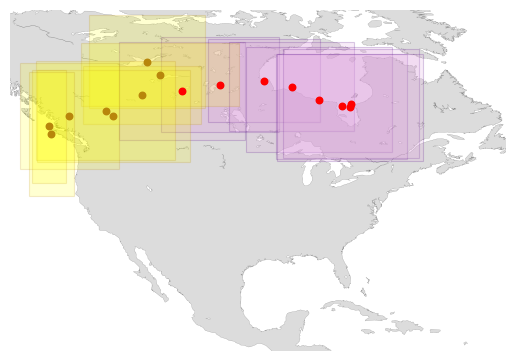

Saved at 300 DPI: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Cluster0_and_Cluster1_MeanStd_300dpi.svg


In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================
mean_file0 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Cluster_0_mean_std.xlsx"
mean_file1 = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\Cluster_1_mean_std.xlsx"

out_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "Cluster0_and_Cluster1_MeanStd_300dpi.svg")

# ============================================================
# 1) READ DATA (CLUSTER 0 + CLUSTER 1)
# ============================================================
df0 = pd.read_excel(mean_file0)
df0 = df0[df0["cluster"] == 0].copy().sort_values("lead_day")

df1 = pd.read_excel(mean_file1)
df1 = df1[df1["cluster"] == 1].copy().sort_values("lead_day")

# ============================================================
# 2) BASEMAP (ONE PLOT FOR BOTH)
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 3.8))

m = Basemap(
    projection="cyl",
    llcrnrlon=-135, urcrnrlon=-55,
    llcrnrlat=15,   urcrnrlat=70,
    resolution="l",
    ax=ax
)

m.drawmapboundary(fill_color="white", linewidth=0)
m.fillcontinents(color="gainsboro", lake_color="white")
m.drawcoastlines(linewidth=0.15, color="gray")
ax.set_axis_off()

# ============================================================
# 3) HELPER: PLOT BOXES + POINTS
#    (REMOVE lead_day = 9 and 10)
# ============================================================
def plot_cluster(df, box_face, box_edge, point_color,
                 shrink_factor=0.8, skip_day0=True,
                 point_size=22, box_alpha=0.10, box_lw=0.8):

    lead = df["lead_day"].values
    mlat = df["mean_lat"].values
    mlon = df["mean_lon"].values
    slat = df["std_lat"].values
    slon = df["std_lon"].values

    # ---- boxes
    for ld, lon_c, lat_c, dlon, dlat in zip(lead, mlon, mlat, slon, slat):

        if skip_day0 and ld == 0:
            continue
        if ld in (9, 10):   # <<< REMOVE day 9 & 10
            continue
        if np.isnan(lon_c) or np.isnan(lat_c) or np.isnan(dlon) or np.isnan(dlat):
            continue

        dlon_s = dlon * shrink_factor
        dlat_s = dlat * shrink_factor

        rect = Rectangle(
            (lon_c - dlon_s, lat_c - dlat_s),
            2 * dlon_s,
            2 * dlat_s,
            facecolor=box_face,
            alpha=box_alpha,
            edgecolor=box_edge,
            linewidth=box_lw,
            zorder=2
        )
        ax.add_patch(rect)

    # ---- points
    mask = np.ones_like(lead, dtype=bool)

    if skip_day0:
        mask &= (lead != 0)

    mask &= (~np.isin(lead, [9, 10]))   # <<< REMOVE day 9 & 10

    m.scatter(
        mlon[mask],
        mlat[mask],
        s=point_size,
        c=point_color,
        zorder=10
    )

# ============================================================
# 4) PLOT BOTH CLUSTERS ON SAME MAP
# ============================================================

# Cluster 0 (standing)
plot_cluster(
    df0,
    box_face="plum",
    box_edge="indigo",
    point_color="red",
    shrink_factor=0.9,
    skip_day0=True,
    point_size=22,
    box_alpha=0.20,
    box_lw=0.8
)

# Cluster 1 (propagating)
plot_cluster(
    df1,
    box_face="yellow",
    box_edge="darkgoldenrod",
    point_color="darkgoldenrod",
    shrink_factor=0.9,
    skip_day0=True,
    point_size=22,
    box_alpha=0.18,
    box_lw=0.8
)

# ============================================================
# 5) SAVE 300 DPI
# ============================================================
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved at 300 DPI:", out_png)


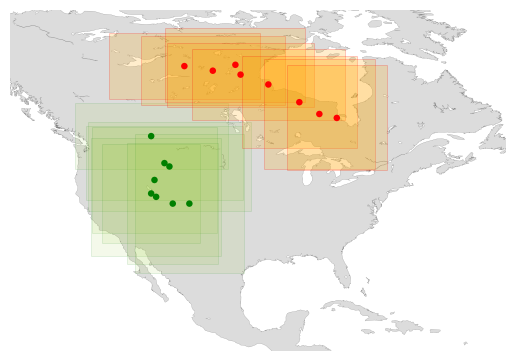

Saved:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\CouplingP_Cluster0_Cluster1_Combined_8days.svg


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle

# ============================================================
# PATHS
# ============================================================

mean_file0 = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration"
    r"\Processing\Processed Data\Step-7_Mechanism"
    r"\North_America\CouplingP_Cluster_0_mean_std.xlsx"
)

mean_file1 = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration"
    r"\Processing\Processed Data\Step-7_Mechanism"
    r"\North_America\CouplingP_Cluster_1_mean_std.xlsx"
)

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration"
    r"\Results"
)

os.makedirs(out_dir, exist_ok=True)

out_svg = os.path.join(
    out_dir,
    "CouplingP_Cluster0_Cluster1_Combined_8days.svg"
)

# ============================================================
# READ DATA
# ============================================================

df0 = pd.read_excel(mean_file0)

df0 = (
    df0[df0["cluster"] == 0]
    .copy()
    .sort_values("lead_day")
)

df1 = pd.read_excel(mean_file1)

df1 = (
    df1[df1["cluster"] == 1]
    .copy()
    .sort_values("lead_day")
)

# ============================================================
# KEEP ONLY LEAD DAYS 1–8
# ============================================================

df0 = df0[
    (df0["lead_day"] >= 1) &
    (df0["lead_day"] <= 8)
].copy()

df1 = df1[
    (df1["lead_day"] >= 1) &
    (df1["lead_day"] <= 8)
].copy()

# ============================================================
# BASEMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 3.8)
)

m = Basemap(
    projection="cyl",
    llcrnrlon=-135,
    urcrnrlon=-55,
    llcrnrlat=15,
    urcrnrlat=70,
    resolution="l",
    ax=ax
)

m.drawmapboundary(
    fill_color="white",
    linewidth=0
)

m.fillcontinents(
    color="gainsboro",
    lake_color="white"
)

m.drawcoastlines(
    linewidth=0.15,
    color="gray"
)

ax.set_axis_off()

# ============================================================
# HELPER FUNCTION
# ============================================================

def plot_cluster(
    df,
    box_face,
    box_edge,
    point_color,
    shrink_factor=0.8,
    point_size=22,
    box_alpha=0.10,
    box_lw=0.7
):

    lead = df["lead_day"].to_numpy()

    mlat = df["mean_lat"].to_numpy(dtype=float)
    mlon = df["mean_lon"].to_numpy(dtype=float)

    slat = df["std_lat"].to_numpy(dtype=float)
    slon = df["std_lon"].to_numpy(dtype=float)

    # ========================================================
    # BOXES — ONLY DAYS 1–8
    # ========================================================

    for ld, lon, lat, dlon, dlat in zip(
        lead,
        mlon,
        mlat,
        slon,
        slat
    ):

        if not (1 <= ld <= 8):
            continue

        if (
            np.isnan(lon)
            or np.isnan(lat)
            or np.isnan(dlon)
            or np.isnan(dlat)
        ):
            continue

        rect = Rectangle(
            (
                lon - dlon * shrink_factor,
                lat - dlat * shrink_factor
            ),
            2 * dlon * shrink_factor,
            2 * dlat * shrink_factor,
            facecolor=box_face,
            edgecolor=box_edge,
            alpha=box_alpha,
            linewidth=box_lw,
            zorder=2
        )

        ax.add_patch(rect)

    # ========================================================
    # POINTS — EXACTLY DAYS 1–8
    # ========================================================

    valid = (
        (lead >= 1) &
        (lead <= 8) &
        np.isfinite(mlon) &
        np.isfinite(mlat)
    )

    m.scatter(
        mlon[valid],
        mlat[valid],
        s=point_size,
        c=point_color,
        edgecolors="none",
        zorder=10
    )

# ============================================================
# CLUSTER 0
# ============================================================

plot_cluster(
    df0,
    box_face="yellowgreen",
    box_edge="green",
    point_color="green",
    shrink_factor=0.8,
    point_size=22,
    box_alpha=0.10,
    box_lw=0.7
)

# ============================================================
# CLUSTER 1
# ============================================================

plot_cluster(
    df1,
    box_face="orange",
    box_edge="red",
    point_color="red",
    shrink_factor=0.9,
    point_size=22,
    box_alpha=0.20,
    box_lw=0.7
)

# ============================================================
# SAVE SVG
# ============================================================

plt.tight_layout()

plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

plt.show()

print("Saved:")
print(out_svg)

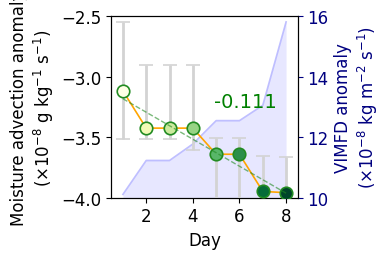


Saved PNG:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Propagating_Advection_VIMFD_FilledArea_300dpi.png

Saved VECTOR PDF:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Propagating_Advection_VIMFD_FilledArea_VECTOR.pdf

Saved VECTOR SVG:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\step-10 _Migration_usa\Propagating_Advection_VIMFD_FilledArea_VECTOR.svg

Advection fit: slope=-0.111404, intercept=-3.07158
VIMFD fit: slope=0.639219, intercept=9.41056


In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

ADV_SCALE = 1e8
VIMFD_SCALE = 1e8

adv_path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
)

vimfd_path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\Propagating_daywise_mean_std_VIMFD1000_300.xlsx"
)

# Save current analysis folder
out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\step-10 _Migration_usa"
)

os.makedirs(out_dir, exist_ok=True)

# Raster
out_png = os.path.join(
    out_dir,
    "Propagating_Advection_VIMFD_FilledArea_300dpi.png"
)

# VECTOR PDF
out_pdf = os.path.join(
    out_dir,
    "Propagating_Advection_VIMFD_FilledArea_VECTOR.pdf"
)

# VECTOR SVG
out_svg = os.path.join(
    out_dir,
    "Propagating_Advection_VIMFD_FilledArea_VECTOR.svg"
)

# ============================================================
# IMPORTANT FOR EDITABLE VECTOR TEXT
# ============================================================

# Keep text as text in PDF
mpl.rcParams["pdf.fonttype"] = 42

# Keep text as text in PostScript/PDF workflows
mpl.rcParams["ps.fonttype"] = 42

# Keep SVG text editable as text
mpl.rcParams["svg.fonttype"] = "none"

# ============================================================
# FIXED Y-TICKS
# ============================================================

ADV_Y_TICKS = [
    -4.0,
    -3.5,
    -3.0,
    -2.5
]

VIMFD_Y_TICKS = [
    10,
    12,
    14,
    16
]

# ============================================================
# READ ADVECTION DATA
# ============================================================

df_adv = pd.read_excel(
    adv_path
).sort_values(
    "day_count"
)

df_adv = df_adv[
    (df_adv["day_count"] >= 1)
    &
    (df_adv["day_count"] <= 8)
].copy()

days = (
    df_adv["day_count"]
    .values
    .astype(float)
)

# moisture advection:
# kg/kg/s -> g/kg/s
# then displayed as ×10^-8

adv_p50 = (
    df_adv["moist_p50"].values
    *
    1000.0
    *
    ADV_SCALE
)

adv_p25 = (
    df_adv["moist_p25"].values
    *
    1000.0
    *
    ADV_SCALE
)

adv_p75 = (
    df_adv["moist_p75"].values
    *
    1000.0
    *
    ADV_SCALE
)

# Linear fit
adv_slope, adv_intercept = np.polyfit(
    days,
    adv_p50,
    1
)

adv_fit = (
    adv_slope * days
    +
    adv_intercept
)

# ============================================================
# READ VIMFD DATA
# ============================================================

df_vimfd = pd.read_excel(
    vimfd_path
).sort_values(
    "day_count"
)

df_vimfd = df_vimfd[
    (df_vimfd["day_count"] >= 1)
    &
    (df_vimfd["day_count"] <= 8)
].copy()

vimfd_days = (
    df_vimfd["day_count"]
    .values
    .astype(float)
)

vimfd_p50 = (
    df_vimfd["moistdiv_p50"].values
    *
    VIMFD_SCALE
)

vimfd_slope, vimfd_intercept = np.polyfit(
    vimfd_days,
    vimfd_p50,
    1
)

vimfd_fit = (
    vimfd_slope * vimfd_days
    +
    vimfd_intercept
)

# ============================================================
# COLORMAP FOR ADVECTION POINTS
# ============================================================

cmap = plt.cm.YlGn

norm = mpl.colors.Normalize(
    vmin=days.min(),
    vmax=days.max()
)

# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(4, 2.7)
)

ax2 = ax1.twinx()

# ============================================================
# RIGHT AXIS = VIMFD FILLED AREA
# ============================================================

vimfd_base = 10.0

ax2.fill_between(
    vimfd_days,
    vimfd_base,
    vimfd_p50,
    color="blue",
    alpha=0.095,
    linewidth=0,
    zorder=1
)

ax2.plot(
    vimfd_days,
    vimfd_p50,
    color="blue",
    linewidth=1.2,
    alpha=0.25,
    zorder=2
)

# ============================================================
# LEFT AXIS = MOISTURE ADVECTION
# ============================================================

for d, m, lo, hi in zip(
    days,
    adv_p50,
    adv_p25,
    adv_p75
):

    c = cmap(
        norm(d)
    )

    yerr = np.array(
        [
            [m - lo],
            [hi - m]
        ]
    )

    ax1.errorbar(
        d,
        m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="forestgreen",
        markeredgewidth=1.2,
        elinewidth=2,
        capsize=5,
        zorder=5
    )

# ============================================================
# CONNECT MEDIANS
# ============================================================

ax1.plot(
    days,
    adv_p50,
    color="orange",
    linewidth=1.2,
    zorder=4
)

# ============================================================
# ADVECTION LINEAR TREND
# ============================================================

ax1.plot(
    days,
    adv_fit,
    color="forestgreen",
    linewidth=1,
    linestyle="--",
    alpha=0.6,
    zorder=6
)

# ============================================================
# SLOPE TEXT
# ============================================================

ax1.text(
    0.55,
    0.58,
    f"{adv_slope:+.3g}",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color="green"
)

# ============================================================
# AXES LABELS
# ============================================================

ax1.set_xlabel(
    "Day",
    fontsize=12
)

ax1.set_ylabel(
    "Moisture advection anomaly\n"
    r"($\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=12,
    color="black"
)

ax2.set_ylabel(
    "VIMFD anomaly\n"
    r"($\times 10^{-8}$ kg m$^{-2}$ s$^{-1}$)",
    fontsize=12,
    color="navy"
)

# ============================================================
# AXES LIMITS / TICKS
# ============================================================

ax1.set_xlim(
    0.5,
    8.5
)

ax1.set_xticks(
    [2, 4, 6, 8]
)

ax1.set_ylim(
    -4.0,
    -2.5
)

ax1.set_yticks(
    ADV_Y_TICKS
)

ax2.set_ylim(
    10.0,
    16.0
)

ax2.set_yticks(
    VIMFD_Y_TICKS
)

ax1.tick_params(
    axis="x",
    labelsize=12
)

ax1.tick_params(
    axis="y",
    labelsize=12,
    colors="black"
)

ax2.tick_params(
    axis="y",
    labelsize=12,
    colors="navy"
)

# ============================================================
# STYLE
# ============================================================

ax1.grid(False)
ax2.grid(False)

ax1.set_facecolor(
    "white"
)

fig.patch.set_facecolor(
    "white"
)

# Keep advection axis above filled VIMFD
ax1.set_zorder(3)
ax2.set_zorder(2)

ax1.patch.set_alpha(
    0
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE PNG — RASTER
# ============================================================

plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# ============================================================
# SAVE PDF — VECTOR
# ============================================================

plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# ============================================================
# SAVE SVG — VECTOR
# ============================================================

plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

# ============================================================
# SHOW
# ============================================================

plt.show()

# ============================================================
# OUTPUT
# ============================================================

print("\nSaved PNG:")
print(out_png)

print("\nSaved VECTOR PDF:")
print(out_pdf)

print("\nSaved VECTOR SVG:")
print(out_svg)

print(
    f"\nAdvection fit: "
    f"slope={adv_slope:.6g}, "
    f"intercept={adv_intercept:.6g}"
)

print(
    f"VIMFD fit: "
    f"slope={vimfd_slope:.6g}, "
    f"intercept={vimfd_intercept:.6g}"
)

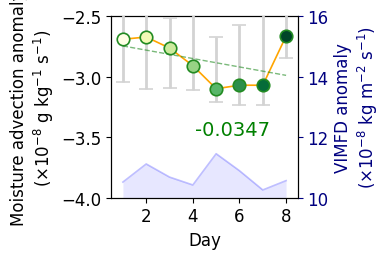


Saved PNG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_Advection_VIMFD_FilledArea_StyleMatched_300dpi.png

Saved VECTOR PDF:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_Advection_VIMFD_FilledArea_StyleMatched_VECTOR.pdf

Saved VECTOR SVG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_Advection_VIMFD_FilledArea_StyleMatched_VECTOR.svg

Advection fit: slope=-0.0346931, intercept=-2.71241
VIMFD fit: slope=-0.0273651, intercept=10.8604


In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

ADV_SCALE = 1e8
VIMFD_SCALE = 1e8

adv_path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
)

vimfd_path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\Standing_daywise_mean_std_VIMFD1000_300.xlsx"
)

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
)

os.makedirs(out_dir, exist_ok=True)

# ============================================================
# OUTPUT FILES
# ============================================================

out_png = os.path.join(
    out_dir,
    "Standing_Advection_VIMFD_FilledArea_StyleMatched_300dpi.png"
)

out_pdf = os.path.join(
    out_dir,
    "Standing_Advection_VIMFD_FilledArea_StyleMatched_VECTOR.pdf"
)

out_svg = os.path.join(
    out_dir,
    "Standing_Advection_VIMFD_FilledArea_StyleMatched_VECTOR.svg"
)

# ============================================================
# VECTOR FONT SETTINGS
# ============================================================

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# Keep SVG text as editable text
mpl.rcParams["svg.fonttype"] = "none"

# ============================================================
# FIXED Y-TICKS
# ============================================================

ADV_Y_TICKS = [-4.0, -3.5, -3.0, -2.5]
VIMFD_Y_TICKS = [10, 12, 14, 16]

# ============================================================
# READ ADVECTION DATA
# ============================================================

df_adv = pd.read_excel(
    adv_path
).sort_values(
    "day_count"
)

df_adv = df_adv[
    (df_adv["day_count"] >= 1)
    &
    (df_adv["day_count"] <= 8)
].copy()

days = (
    df_adv["day_count"]
    .values
    .astype(float)
)

# moisture advection:
# kg/kg/s -> g/kg/s, then display as ×10^-8

adv_p50 = (
    df_adv["moist_p50"].values
    *
    1000.0
    *
    ADV_SCALE
)

adv_p25 = (
    df_adv["moist_p25"].values
    *
    1000.0
    *
    ADV_SCALE
)

adv_p75 = (
    df_adv["moist_p75"].values
    *
    1000.0
    *
    ADV_SCALE
)

adv_slope, adv_intercept = np.polyfit(
    days,
    adv_p50,
    1
)

adv_fit = (
    adv_slope * days
    +
    adv_intercept
)

# ============================================================
# READ VIMFD DATA
# ============================================================

df_vimfd = pd.read_excel(
    vimfd_path
).sort_values(
    "day_count"
)

df_vimfd = df_vimfd[
    (df_vimfd["day_count"] >= 1)
    &
    (df_vimfd["day_count"] <= 8)
].copy()

vimfd_days = (
    df_vimfd["day_count"]
    .values
    .astype(float)
)

# VIMFD anomaly: display as ×10^-8

vimfd_p50 = (
    df_vimfd["moistdiv_p50"].values
    *
    VIMFD_SCALE
)

vimfd_slope, vimfd_intercept = np.polyfit(
    vimfd_days,
    vimfd_p50,
    1
)

vimfd_fit = (
    vimfd_slope * vimfd_days
    +
    vimfd_intercept
)

# ============================================================
# COLORMAP FOR ADVECTION POINTS
# ============================================================

cmap = plt.cm.YlGn

norm = mpl.colors.Normalize(
    vmin=days.min(),
    vmax=days.max()
)

# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(4, 2.7)
)

ax2 = ax1.twinx()

# ============================================================
# RIGHT AXIS = VIMFD FILLED AREA IN BACKGROUND
# ============================================================

vimfd_base = 10.0

ax2.fill_between(
    vimfd_days,
    vimfd_base,
    vimfd_p50,
    color="blue",
    alpha=0.095,
    linewidth=0,
    zorder=1
)

ax2.plot(
    vimfd_days,
    vimfd_p50,
    color="blue",
    linewidth=1.2,
    alpha=0.25,
    zorder=2
)

# ============================================================
# LEFT AXIS = MOISTURE ADVECTION POINTS + ERROR BARS
# ============================================================

for d, m, lo, hi in zip(
    days,
    adv_p50,
    adv_p25,
    adv_p75
):

    c = cmap(
        norm(d)
    )

    yerr = np.array(
        [
            [m - lo],
            [hi - m]
        ]
    )

    ax1.errorbar(
        d,
        m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="forestgreen",
        markeredgewidth=1.2,
        elinewidth=2,
        capsize=5,
        zorder=5
    )

# ============================================================
# CONNECT MEDIANS
# ============================================================

ax1.plot(
    days,
    adv_p50,
    color="orange",
    linewidth=1.2,
    zorder=4
)

# ============================================================
# ADVECTION LINEAR TREND
# ============================================================

ax1.plot(
    days,
    adv_fit,
    color="forestgreen",
    linewidth=1,
    linestyle="--",
    alpha=0.6,
    zorder=6
)

# ============================================================
# SLOPE TEXT
# ============================================================

ax1.text(
    0.45,
    0.428,
    f"{adv_slope:+.3g}",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color="green"
)

# ============================================================
# AXES LABELS
# ============================================================

ax1.set_xlabel(
    "Day",
    fontsize=12
)

ax1.set_ylabel(
    "Moisture advection anomaly\n"
    r"($\times 10^{-8}$ g kg$^{-1}$ s$^{-1}$)",
    fontsize=12,
    color="black"
)

ax2.set_ylabel(
    "VIMFD anomaly\n"
    r"($\times 10^{-8}$ kg m$^{-2}$ s$^{-1}$)",
    fontsize=12,
    color="navy"
)

# ============================================================
# AXES LIMITS / TICKS
# ============================================================

ax1.set_xlim(
    0.5,
    8.5
)

ax1.set_xticks(
    [2, 4, 6, 8]
)

ax1.set_ylim(
    -4.0,
    -2.5
)

ax1.set_yticks(
    ADV_Y_TICKS
)

ax2.set_ylim(
    10.0,
    16.0
)

ax2.set_yticks(
    VIMFD_Y_TICKS
)

ax1.tick_params(
    axis="x",
    labelsize=12
)

ax1.tick_params(
    axis="y",
    labelsize=12,
    colors="black"
)

ax2.tick_params(
    axis="y",
    labelsize=12,
    colors="navy"
)

# ============================================================
# STYLE
# ============================================================

ax1.grid(False)
ax2.grid(False)

ax1.set_facecolor(
    "white"
)

fig.patch.set_facecolor(
    "white"
)

# keep advection axis above blue area
ax1.set_zorder(3)
ax2.set_zorder(2)

ax1.patch.set_alpha(
    0
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

# PNG — 300 dpi
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# PDF — vector
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# SVG — vector/editable
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

plt.show()

# ============================================================
# OUTPUT
# ============================================================

print("\nSaved PNG:")
print(out_png)

print("\nSaved VECTOR PDF:")
print(out_pdf)

print("\nSaved VECTOR SVG:")
print(out_svg)

print(
    f"\nAdvection fit: "
    f"slope={adv_slope:.6g}, "
    f"intercept={adv_intercept:.6g}"
)

print(
    f"VIMFD fit: "
    f"slope={vimfd_slope:.6g}, "
    f"intercept={vimfd_intercept:.6g}"
)

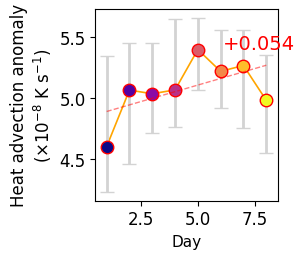


Saved PNG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_HeatAdvection_Days1to8_LinearFit_300dpi.png

Saved VECTOR PDF:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_HeatAdvection_Days1to8_LinearFit_VECTOR.pdf

Saved VECTOR SVG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Standing_HeatAdvection_Days1to8_LinearFit_VECTOR.svg

Linear fit: slope=0.0543286, intercept=4.83635 (units after scaling)


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS
# ============================================================

SCALE = 1e8  # rescale from ~1e-8

path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America\Standing_daywise_mean_std.xlsx"
)

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
)

os.makedirs(
    out_dir,
    exist_ok=True
)

# ============================================================
# OUTPUT FILES
# ============================================================

out_png = os.path.join(
    out_dir,
    "Standing_HeatAdvection_Days1to8_LinearFit_300dpi.png"
)

out_pdf = os.path.join(
    out_dir,
    "Standing_HeatAdvection_Days1to8_LinearFit_VECTOR.pdf"
)

out_svg = os.path.join(
    out_dir,
    "Standing_HeatAdvection_Days1to8_LinearFit_VECTOR.svg"
)

# ============================================================
# VECTOR FONT SETTINGS
# ============================================================

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# ============================================================
# READ + FILTER (ONLY DAYS 1–8)
# ============================================================

df = (
    pd.read_excel(path)
    .sort_values("day_count")
)

df = df[
    (df["day_count"] >= 1)
    &
    (df["day_count"] <= 8)
].copy()

days = (
    df["day_count"]
    .values
    .astype(float)
)

med = (
    df["heat_p50"].values
    *
    SCALE
)

q25 = (
    df["heat_p25"].values
    *
    SCALE
)

q75 = (
    df["heat_p75"].values
    *
    SCALE
)

# ============================================================
# LINEAR FIT
# ============================================================

slope, intercept = np.polyfit(
    days,
    med,
    1
)

fit_y = (
    slope * days
    +
    intercept
)

# ============================================================
# COLORMAP
# ============================================================

cmap = plt.cm.plasma

norm = mpl.colors.Normalize(
    vmin=days.min(),
    vmax=days.max()
)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(3, 2.7)
)

# ============================================================
# ERROR BARS + POINTS
# ============================================================

for d, m, lo, hi in zip(
    days,
    med,
    q25,
    q75
):

    c = cmap(
        norm(d)
    )

    yerr = np.array(
        [
            [m - lo],
            [hi - m]
        ]
    )

    ax.errorbar(
        d,
        m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="red",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# ============================================================
# CONNECT MEDIANS
# ============================================================

ax.plot(
    days,
    med,
    color="orange",
    linewidth=1.2,
    zorder=2
)

# ============================================================
# LINEAR TREND
# ============================================================

ax.plot(
    days,
    fit_y,
    color="red",
    linewidth=1,
    linestyle="--",
    alpha=0.5,
    zorder=4
)

# ============================================================
# SLOPE TEXT
# ============================================================

eq_text = f"{slope:+.2g}"

ax.text(
    0.7,
    0.87,
    eq_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color="red"
)

# ============================================================
# AXES LABELS
# ============================================================

ax.set_xlabel(
    "Day",
    fontsize=11
)

ax.set_ylabel(
    "Heat advection anomaly\n"
    r"($\times 10^{-8}$ K s$^{-1}$)",
    fontsize=12
)

ax.set_xlim(
    0.5,
    8.5
)

ax.tick_params(
    labelsize=12
)

# ============================================================
# STYLE
# ============================================================

ax.grid(False)

ax.set_facecolor(
    "white"
)

fig.patch.set_facecolor(
    "white"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

# PNG
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# VECTOR PDF
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# VECTOR SVG
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

plt.show()

# ============================================================
# OUTPUT
# ============================================================

print("\nSaved PNG:")
print(out_png)

print("\nSaved VECTOR PDF:")
print(out_pdf)

print("\nSaved VECTOR SVG:")
print(out_svg)

print(
    f"\nLinear fit: "
    f"slope={slope:.6g}, "
    f"intercept={intercept:.6g} "
    "(units after scaling)"
)

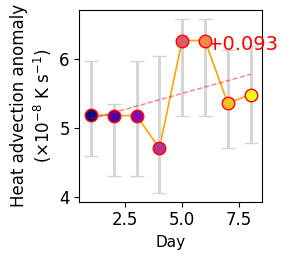


Saved PNG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_LinearFit_300dpi.png

Saved VECTOR PDF:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_LinearFit_VECTOR.pdf

Saved VECTOR SVG:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Propagating_HeatAdvection_Days1to8_LinearFit_VECTOR.svg

Linear fit: slope=0.092551, intercept=5.04005 (units after scaling)


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os

# ============================================================
# SETTINGS
# ============================================================

SCALE = 1e8  # rescale from ~1e-8

path = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America\Propagating_daywise_mean_std.xlsx"
)

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
)

os.makedirs(
    out_dir,
    exist_ok=True
)

# ============================================================
# OUTPUT FILES
# ============================================================

out_png = os.path.join(
    out_dir,
    "Propagating_HeatAdvection_Days1to8_LinearFit_300dpi.png"
)

out_pdf = os.path.join(
    out_dir,
    "Propagating_HeatAdvection_Days1to8_LinearFit_VECTOR.pdf"
)

out_svg = os.path.join(
    out_dir,
    "Propagating_HeatAdvection_Days1to8_LinearFit_VECTOR.svg"
)

# ============================================================
# VECTOR FONT SETTINGS
# ============================================================

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# ============================================================
# READ + FILTER ONLY DAYS 1–8
# ============================================================

df = (
    pd.read_excel(path)
    .sort_values("day_count")
)

df = df[
    (df["day_count"] >= 1)
    &
    (df["day_count"] <= 8)
].copy()

days = (
    df["day_count"]
    .values
    .astype(float)
)

med = (
    df["heat_p50"].values
    *
    SCALE
)

q25 = (
    df["heat_p25"].values
    *
    SCALE
)

q75 = (
    df["heat_p75"].values
    *
    SCALE
)

# ============================================================
# LINEAR FIT
# ============================================================

slope, intercept = np.polyfit(
    days,
    med,
    1
)

fit_y = (
    slope * days
    +
    intercept
)

# ============================================================
# COLORMAP
# ============================================================

cmap = plt.cm.plasma

norm = mpl.colors.Normalize(
    vmin=days.min(),
    vmax=days.max()
)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(3, 2.7)
)

# ============================================================
# ERROR BARS + POINTS
# ============================================================

for d, m, lo, hi in zip(
    days,
    med,
    q25,
    q75
):

    c = cmap(
        norm(d)
    )

    yerr = np.array(
        [
            [m - lo],
            [hi - m]
        ]
    )

    ax.errorbar(
        d,
        m,
        yerr=yerr,
        fmt="o",
        color=c,
        ecolor="lightgrey",
        markersize=9,
        markerfacecolor=c,
        markeredgecolor="red",
        elinewidth=2,
        capsize=5,
        zorder=3
    )

# ============================================================
# CONNECT MEDIANS
# ============================================================

ax.plot(
    days,
    med,
    color="orange",
    linewidth=1.2,
    zorder=2
)

# ============================================================
# LINEAR TREND
# ============================================================

ax.plot(
    days,
    fit_y,
    color="red",
    linewidth=1,
    linestyle="--",
    alpha=0.5,
    zorder=4
)

# ============================================================
# SLOPE TEXT
# ============================================================

eq_text = f"{slope:+.2g}"

ax.text(
    0.7,
    0.87,
    eq_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color="red"
)

# ============================================================
# AXES LABELS
# ============================================================

ax.set_xlabel(
    "Day",
    fontsize=11
)

ax.set_ylabel(
    "Heat advection anomaly\n"
    r"($\times 10^{-8}$ K s$^{-1}$)",
    fontsize=12
)

ax.set_xlim(
    0.5,
    8.5
)

ax.tick_params(
    labelsize=12
)

# ============================================================
# STYLE
# ============================================================

ax.grid(False)

ax.set_facecolor(
    "white"
)

fig.patch.set_facecolor(
    "white"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

# PNG — raster
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

# PDF — vector
plt.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

# SVG — vector/editable
plt.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight",
    transparent=True
)

plt.show()

# ============================================================
# OUTPUT
# ============================================================

print("\nSaved PNG:")
print(out_png)

print("\nSaved VECTOR PDF:")
print(out_pdf)

print("\nSaved VECTOR SVG:")
print(out_svg)

print(
    f"\nLinear fit: "
    f"slope={slope:.6g}, "
    f"intercept={intercept:.6g} "
    "(units after scaling)"
)

Rows in full North America sample: 417
Rows in 89-event subset: 89

Variable: Duration
subset_col = duration
full_col   = duration

Variable: Displacement
subset_col = distance
full_col   = distance

Variable: Total Distance
subset_col = total distance
full_col   = total distance

Variable: Moving Speed
subset_col = moving speed
full_col   = moving speed


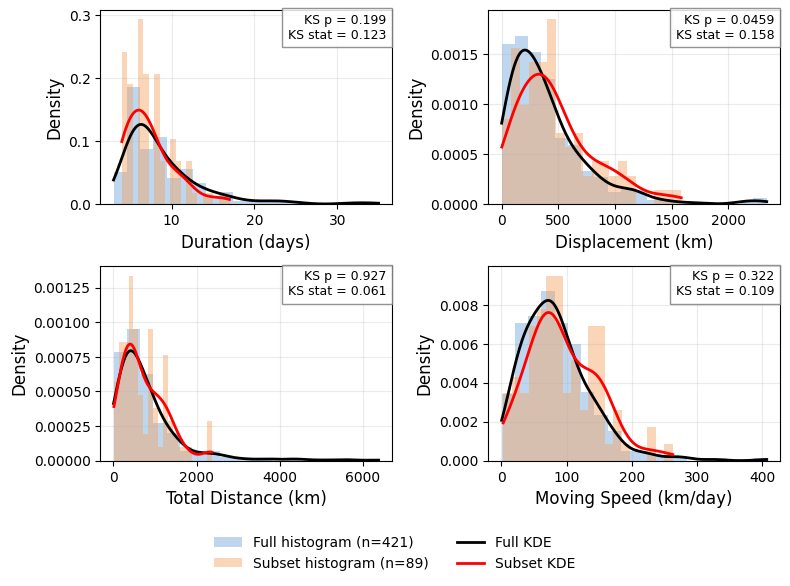


Saved figure to: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Subset_vs_Full_Distribution_Check\Subset_vs_Full_2x2_Displacement_units_bottomlabels.png
Saved statistics table to: D:\PhD_Research\Paper-3_CHDW_Migration\Results\Subset_vs_Full_Distribution_Check\Subset_vs_Full_2x2_Displacement_units_bottomlabels_stats.xlsx

Summary:
         Variable  KS_p_value   KS_stat          Interpretation
0        Duration    0.198650  0.122868         Broadly similar
1    Displacement    0.045910  0.157681  Different distribution
2  Total Distance    0.926878  0.061299         Broadly similar
3    Moving Speed    0.322274  0.108884         Broadly similar

Most different variable based on KS statistic:
Displacement | KS stat = 0.158 | KS p = 0.0459


In [43]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, gaussian_kde

# ============================================================
# PATHS
# ============================================================
subset_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America_421_with_89_subset_flag.xlsx"
full_file = r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step_4_Event_Calculation\Event_Observ\Updated_Event_Displacement_Direction_With_Continent.xlsx"

output_dir = r"D:\PhD_Research\Paper-3_CHDW_Migration\Results\Subset_vs_Full_Distribution_Check"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# VARIABLES FOR 2x2 PANEL
# ============================================================
variables_to_compare = [
    "Duration",
    "Displacement",
    "Total Distance",
    "Moving Speed"
]

# ============================================================
# AXIS LABELS WITH UNITS
# ============================================================
xaxis_labels = {
    "Duration": "Duration (days)",
    "Displacement": "Displacement (km)",
    "Total Distance": "Total Distance (km)",
    "Moving Speed": "Moving Speed (km/day)"
}

# ============================================================
# COLORS
# ============================================================
FULL_HIST_COLOR = "#6FA8DC"      # blue
SUBSET_HIST_COLOR = "#F4A261"    # orange
FULL_KDE_COLOR = "black"
SUBSET_KDE_COLOR = "red"

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def clean_name(x):
    x = str(x)
    x = x.replace("\xa0", " ")
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r"\s+", " ", x).strip().lower()
    return x

def normalize_columns(df):
    df = df.copy()
    df.columns = [clean_name(c) for c in df.columns]
    return df

def find_column(df, candidates):
    colmap = {clean_name(c): c for c in df.columns}
    for cand in candidates:
        key = clean_name(cand)
        if key in colmap:
            return colmap[key]
    return None

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce").dropna()

def interpret_ks_pvalue(p):
    if p >= 0.05:
        return "Broadly similar"
    else:
        return "Different distribution"

def summarize_group(x):
    return {
        "n": len(x),
        "mean": np.mean(x) if len(x) > 0 else np.nan,
        "median": np.median(x) if len(x) > 0 else np.nan,
        "std": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "min": np.min(x) if len(x) > 0 else np.nan,
        "max": np.max(x) if len(x) > 0 else np.nan
    }

def add_density(ax, data, color, linewidth=2):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if len(data) < 3:
        return
    if len(np.unique(data)) < 2:
        return

    try:
        kde = gaussian_kde(data)
        xmin = np.nanmin(data)
        xmax = np.nanmax(data)
        if xmin == xmax:
            return
        xgrid = np.linspace(xmin, xmax, 300)
        ygrid = kde(xgrid)
        ax.plot(xgrid, ygrid, color=color, linewidth=linewidth)
    except Exception:
        pass

# ============================================================
# LOAD FILES
# ============================================================
subset_df = pd.read_excel(subset_file, sheet_name="All_421_with_flag")
full_df = pd.read_excel(full_file)

subset_df = normalize_columns(subset_df)
full_df = normalize_columns(full_df)

# ============================================================
# FIND IMPORTANT COLUMNS
# ============================================================
event_id_subset = find_column(subset_df, ["Event ID"])
event_id_full = find_column(full_df, ["Event ID"])
continent_col_full = find_column(full_df, ["Continent"])
flag_col = find_column(subset_df, ["In_89_Subset"])

if event_id_subset is None or event_id_full is None:
    raise ValueError("Could not find Event ID column.")
if flag_col is None:
    raise ValueError("Could not find In_89_Subset column in subset file.")

# ============================================================
# FULL NORTH AMERICA SAMPLE
# ============================================================
if continent_col_full is not None:
    full_na = full_df[
        full_df[continent_col_full].astype(str).str.strip().str.lower() == "north america"
    ].copy()
else:
    full_na = full_df.copy()

full_na = full_na.drop_duplicates(subset=[event_id_full]).copy()
print("Rows in full North America sample:", len(full_na))

# ============================================================
# 89-EVENT SUBSET
# ============================================================
subset_df[flag_col] = subset_df[flag_col].astype(str).str.strip().str.lower()
subset_use = subset_df[subset_df[flag_col] == "yes"].copy()
subset_use = subset_use.drop_duplicates(subset=[event_id_subset]).copy()
print("Rows in 89-event subset:", len(subset_use))

# ============================================================
# MERGE EXTRA VARIABLES FROM FULL FILE INTO SUBSET
# ============================================================
needed_cols = ["event id", "total distance", "moving speed", "displacement"]
available_merge_cols = [c for c in needed_cols if c in full_df.columns]

merge_df = full_df[available_merge_cols].drop_duplicates(subset=["event id"]).copy()

subset_use = subset_use.merge(
    merge_df,
    left_on=event_id_subset,
    right_on="event id",
    how="left",
    suffixes=("", "_fromfull")
)

# ============================================================
# VARIABLE ALIASES
# ============================================================
var_aliases = {
    "Duration": ["Duration"],
    "Displacement": ["Displacement", "distance", "event displacement"],
    "Total Distance": ["Total Distance", "total distance"],
    "Moving Speed": ["Moving Speed", "moving speed"]
}

# ============================================================
# FIGURE + STATS
# ============================================================
results = []

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, var in enumerate(variables_to_compare):
    ax = axes[i]

    subset_col = find_column(subset_use, var_aliases[var])
    full_col = find_column(full_na, var_aliases[var])

    print(f"\nVariable: {var}")
    print("subset_col =", subset_col)
    print("full_col   =", full_col)

    if subset_col is None or full_col is None:
        ax.set_visible(False)
        continue

    x_subset = safe_numeric(subset_use[subset_col])
    x_full = safe_numeric(full_na[full_col])

    x_subset = x_subset[np.isfinite(x_subset)]
    x_full = x_full[np.isfinite(x_full)]

    if len(x_subset) == 0 or len(x_full) == 0:
        ax.set_visible(False)
        continue

    bins = 20

    ax.hist(
        x_full,
        bins=bins,
        density=True,
        alpha=0.45,
        color=FULL_HIST_COLOR,
        edgecolor="none"
    )

    ax.hist(
        x_subset,
        bins=bins,
        density=True,
        alpha=0.45,
        color=SUBSET_HIST_COLOR,
        edgecolor="none"
    )

    add_density(ax, x_full.values, color=FULL_KDE_COLOR)
    add_density(ax, x_subset.values, color=SUBSET_KDE_COLOR)

    ks_stat, ks_p = ks_2samp(x_subset, x_full)

    s1 = summarize_group(x_subset.values)
    s2 = summarize_group(x_full.values)

    results.append({
        "Variable": var,
        "Subset_n": s1["n"],
        "Full_n": s2["n"],
        "Subset_mean": s1["mean"],
        "Full_mean": s2["mean"],
        "Subset_median": s1["median"],
        "Full_median": s2["median"],
        "Subset_std": s1["std"],
        "Full_std": s2["std"],
        "KS_stat": ks_stat,
        "KS_p_value": ks_p,
        "Interpretation": interpret_ks_pvalue(ks_p)
    })

    txt = (
        f"KS p = {ks_p:.3g}\n"
        f"KS stat = {ks_stat:.3f}"
    )

    ax.text(
        0.98, 0.98, txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
    )

    # REMOVE TITLE FROM TOP
    ax.set_title("")

    # KEEP VARIABLE NAME ONLY AT BOTTOM
    ax.set_xlabel(xaxis_labels[var], fontsize=12)
    ax.set_ylabel("Density", fontsize=12)

    # bottom ticks only
    ax.tick_params(
        axis="x",
        labelsize=10,
        bottom=True,
        top=False,
        labelbottom=True,
        labeltop=False
    )
    ax.tick_params(axis="y", labelsize=10)
    ax.xaxis.set_ticks_position("bottom")

    ax.grid(alpha=0.25)

# ============================================================
# COMMON LEGEND BELOW ALL PANELS
# ============================================================
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=FULL_HIST_COLOR, alpha=0.45, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=SUBSET_HIST_COLOR, alpha=0.45, edgecolor="none"),
    plt.Line2D([0], [0], color=FULL_KDE_COLOR, lw=2),
    plt.Line2D([0], [0], color=SUBSET_KDE_COLOR, lw=2)
]

legend_labels = [
    "Full histogram (n=421)",
    "Subset histogram (n=89)",
    "Full KDE",
    "Subset KDE"
]

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])

fig_path = os.path.join(output_dir, "Subset_vs_Full_2x2_Displacement_units_bottomlabels.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SAVE STATS
# ============================================================
results_df = pd.DataFrame(results)
stats_path = os.path.join(output_dir, "Subset_vs_Full_2x2_Displacement_units_bottomlabels_stats.xlsx")
results_df.to_excel(stats_path, index=False)

print("\nSaved figure to:", fig_path)
print("Saved statistics table to:", stats_path)
print("\nSummary:")
print(results_df[["Variable", "KS_p_value", "KS_stat", "Interpretation"]])

# ============================================================
# MOST DIFFERENT VARIABLE
# ============================================================
if len(results_df) > 0:
    most_important = results_df.sort_values("KS_stat", ascending=False).iloc[0]
    print("\nMost different variable based on KS statistic:")
    print(
        f"{most_important['Variable']} | "
        f"KS stat = {most_important['KS_stat']:.3f} | "
        f"KS p = {most_important['KS_p_value']:.3g}"
    )

C:\Users\Amitesh\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


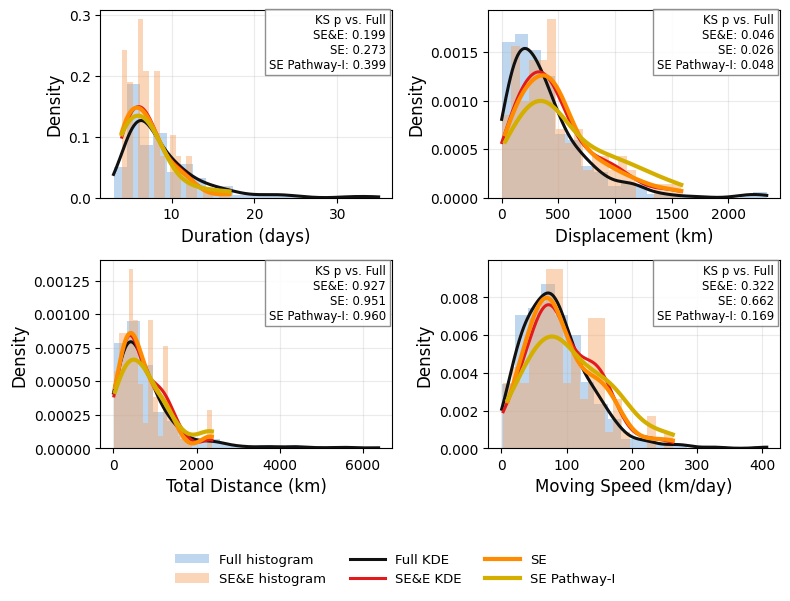

Figure saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Subset_vs_Full_Distribution_Check\Subset_vs_Full_with_SE_and_SE_Pathway_I.png

KS results saved to:
D:\PhD_Research\Paper-3_CHDW_Migration\Results\Subset_vs_Full_Distribution_Check\Subset_vs_Full_with_SE_and_SE_Pathway_I_KS_results.xlsx


In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde, ks_2samp


# ============================================================
# PATHS
# ============================================================
subset_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America_421_with_89_subset_flag.xlsx"
)

full_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step_4_Event_Calculation\Event_Observ"
    r"\Updated_Event_Displacement_Direction_With_Continent.xlsx"
)

# Cluster 1 + SE-direction events
se_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\step-10 _Migration_usa\Cluster1_SE_54_events.xlsx"
)

# Cluster 1 + SE-direction events starting inside the USA
se_pathway_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\Event_Displacement_Cluster1_SE_in_USA.xlsx"
)

output_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
    r"\Subset_vs_Full_Distribution_Check"
)

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# VARIABLES FOR THE 2 × 2 PANEL
# ============================================================
variables_to_compare = [
    "Duration",
    "Displacement",
    "Total Distance",
    "Moving Speed",
]

xaxis_labels = {
    "Duration": "Duration (days)",
    "Displacement": "Displacement (km)",
    "Total Distance": "Total Distance (km)",
    "Moving Speed": "Moving Speed (km/day)",
}

variable_aliases = {
    "Duration": [
        "Duration",
        "event duration",
    ],
    "Displacement": [
        "Displacement",
        "distance",
        "event displacement",
    ],
    "Total Distance": [
        "Total Distance",
        "total migration distance",
    ],
    "Moving Speed": [
        "Moving Speed",
        "migration speed",
    ],
}


# ============================================================
# COLORS
# ============================================================
FULL_HIST_COLOR = "#6FA8DC"       # blue histogram
SEE_HIST_COLOR = "#F4A261"        # peach histogram
FULL_KDE_COLOR = "#111111"        # black KDE
SEE_KDE_COLOR = "#E31A1C"         # red KDE
SE_KDE_COLOR = "#FF8C00"          # orange KDE
PATHWAY_KDE_COLOR = "#D4AF00"     # yellow/gold KDE


# ============================================================
# HELPER FUNCTIONS
# ============================================================
def clean_name(value):
    value = str(value)
    value = value.replace("\xa0", " ")
    value = value.replace("\n", " ")
    value = value.replace("\r", " ")
    value = value.replace("\t", " ")
    return re.sub(r"\s+", " ", value).strip().lower()


def normalize_columns(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = [
        clean_name(column)
        for column in dataframe.columns
    ]
    return dataframe


def find_column(dataframe, candidates):
    column_map = {
        clean_name(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        key = clean_name(candidate)

        if key in column_map:
            return column_map[key]

    return None


def require_column(dataframe, candidates, description):
    column = find_column(dataframe, candidates)

    if column is None:
        raise ValueError(
            f"Could not find the {description} column."
        )

    return column


def event_key(value):
    """
    Standardize event identifiers read from different Excel files.
    """
    if pd.isna(value):
        return ""

    value = str(value).strip()

    if re.fullmatch(r"[-+]?\d+\.0", value):
        value = value[:-2]

    return value.lower()


def safe_numeric(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    return values[
        np.isfinite(values)
    ].dropna()


def prepare_group(
    group_df,
    reference_df,
    reference_event_id,
):
    """
    Ensure that each group contains all four variables.

    Any missing values are matched from the full event table
    using Event ID.
    """
    group_df = group_df.copy()

    group_event_id = find_column(
        group_df,
        ["Event ID"],
    )

    if group_event_id is not None:
        group_df = group_df.drop_duplicates(
            subset=[group_event_id]
        ).copy()

        group_df["_event_key"] = group_df[
            group_event_id
        ].map(event_key)

    reference = reference_df.copy()

    reference["_event_key"] = reference[
        reference_event_id
    ].map(event_key)

    reference = reference.drop_duplicates(
        subset=["_event_key"]
    )

    for variable, aliases in variable_aliases.items():

        group_column = find_column(
            group_df,
            aliases,
        )

        reference_column = find_column(
            reference,
            aliases,
        )

        if reference_column is None:
            raise ValueError(
                f"Could not find '{variable}' "
                "in the full event file."
            )

        if group_event_id is not None:

            reference_lookup = reference.set_index(
                "_event_key"
            )[reference_column]

            matched_values = group_df[
                "_event_key"
            ].map(reference_lookup)

        else:
            matched_values = None

        if group_column is None:

            if matched_values is None:
                raise ValueError(
                    f"'{variable}' is missing and Event ID "
                    "is unavailable for matching."
                )

            group_df[
                clean_name(variable)
            ] = matched_values

        else:

            group_values = pd.to_numeric(
                group_df[group_column],
                errors="coerce",
            )

            if matched_values is not None:
                group_values = group_values.fillna(
                    matched_values
                )

            group_df[group_column] = group_values

    return group_df


def add_density(
    axis,
    data,
    color,
    linewidth=2.2,
    zorder=4,
):
    """
    Draw a KDE density line.
    """
    data = np.asarray(
        data,
        dtype=float,
    )

    data = data[
        np.isfinite(data)
    ]

    if len(data) < 3:
        return

    if len(np.unique(data)) < 2:
        return

    try:
        kde = gaussian_kde(data)

        x_minimum = np.nanmin(data)
        x_maximum = np.nanmax(data)

        if x_minimum == x_maximum:
            return

        x_grid = np.linspace(
            x_minimum,
            x_maximum,
            300,
        )

        axis.plot(
            x_grid,
            kde(x_grid),
            color=color,
            linewidth=linewidth,
            zorder=zorder,
        )

    except (ValueError, np.linalg.LinAlgError):
        pass


def format_pvalue(p_value):
    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


# ============================================================
# LOAD FILES
# ============================================================
subset_df = normalize_columns(
    pd.read_excel(
        subset_file,
        sheet_name="All_421_with_flag",
    )
)

full_df = normalize_columns(
    pd.read_excel(full_file)
)

se_df = normalize_columns(
    pd.read_excel(se_file)
)

se_pathway_df = normalize_columns(
    pd.read_excel(se_pathway_file)
)


# ============================================================
# FULL NORTH AMERICAN DISTRIBUTION
# ============================================================
full_event_id = require_column(
    full_df,
    ["Event ID"],
    "Event ID",
)

continent_column = find_column(
    full_df,
    ["Continent"],
)

if continent_column is not None:

    full_na = full_df[
        full_df[continent_column]
        .astype(str)
        .map(clean_name)
        == "north america"
    ].copy()

else:
    full_na = full_df.copy()


full_na = full_na.drop_duplicates(
    subset=[full_event_id]
).copy()


# ============================================================
# SE&E DISTRIBUTION FROM THE SUBSET FLAG
# ============================================================
subset_event_id = require_column(
    subset_df,
    ["Event ID"],
    "Event ID",
)

flag_column = require_column(
    subset_df,
    ["In_89_Subset"],
    "subset-membership",
)

flag_values = (
    subset_df[flag_column]
    .astype(str)
    .map(clean_name)
)

see_df = subset_df[
    flag_values.isin(
        {
            "yes",
            "y",
            "true",
            "1",
        }
    )
].copy()

see_df = see_df.drop_duplicates(
    subset=[subset_event_id]
).copy()


# ============================================================
# ENSURE ALL GROUPS HAVE THE REQUIRED VARIABLES
# ============================================================
see_df = prepare_group(
    see_df,
    full_na,
    full_event_id,
)

se_df = prepare_group(
    se_df,
    full_na,
    full_event_id,
)

se_pathway_df = prepare_group(
    se_pathway_df,
    full_na,
    full_event_id,
)


# ============================================================
# CREATE FIGURE AND CALCULATE KS TESTS
# ============================================================
results = []

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
)

axes = axes.flatten()


for panel_index, variable in enumerate(
    variables_to_compare
):

    axis = axes[panel_index]

    full_column = require_column(
        full_na,
        variable_aliases[variable],
        variable,
    )

    see_column = require_column(
        see_df,
        variable_aliases[variable],
        variable,
    )

    se_column = require_column(
        se_df,
        variable_aliases[variable],
        variable,
    )

    pathway_column = require_column(
        se_pathway_df,
        variable_aliases[variable],
        variable,
    )

    x_full = safe_numeric(
        full_na[full_column]
    )

    x_see = safe_numeric(
        see_df[see_column]
    )

    x_se = safe_numeric(
        se_df[se_column]
    )

    x_pathway = safe_numeric(
        se_pathway_df[pathway_column]
    )

    if any(
        len(values) == 0
        for values in [
            x_full,
            x_see,
            x_se,
            x_pathway,
        ]
    ):
        axis.set_visible(False)
        continue


    # ========================================================
    # ORIGINAL HISTOGRAMS
    # ========================================================
    axis.hist(
        x_full,
        bins=20,
        density=True,
        alpha=0.45,
        color=FULL_HIST_COLOR,
        edgecolor="none",
        zorder=1,
    )

    axis.hist(
        x_see,
        bins=20,
        density=True,
        alpha=0.45,
        color=SEE_HIST_COLOR,
        edgecolor="none",
        zorder=2,
    )


    # ========================================================
    # ORIGINAL BLACK AND RED KDE LINES
    # ========================================================
    add_density(
        axis,
        x_full,
        color=FULL_KDE_COLOR,
        linewidth=2.2,
        zorder=4,
    )

    add_density(
        axis,
        x_see,
        color=SEE_KDE_COLOR,
        linewidth=2.2,
        zorder=5,
    )


    # ========================================================
    # ORANGE SE LINE ONLY
    # ========================================================
    add_density(
        axis,
        x_se,
        color=SE_KDE_COLOR,
        linewidth=3.0,
        zorder=6,
    )


    # ========================================================
    # YELLOW SE PATHWAY-I LINE ONLY
    # ========================================================
    add_density(
        axis,
        x_pathway,
        color=PATHWAY_KDE_COLOR,
        linewidth=3.0,
        zorder=7,
    )


    # ========================================================
    # KS TESTS AGAINST THE FULL DISTRIBUTION
    # ========================================================
    see_statistic, see_pvalue = ks_2samp(
        x_see,
        x_full,
    )

    se_statistic, se_pvalue = ks_2samp(
        x_se,
        x_full,
    )

    pathway_statistic, pathway_pvalue = ks_2samp(
        x_pathway,
        x_full,
    )


    results.extend(
        [
            {
                "Variable": variable,
                "Comparison": "SE&E vs Full",
                "KS_statistic": see_statistic,
                "KS_p_value": see_pvalue,
            },
            {
                "Variable": variable,
                "Comparison": "SE vs Full",
                "KS_statistic": se_statistic,
                "KS_p_value": se_pvalue,
            },
            {
                "Variable": variable,
                "Comparison": "SE Pathway-I vs Full",
                "KS_statistic": pathway_statistic,
                "KS_p_value": pathway_pvalue,
            },
        ]
    )


    # ========================================================
    # P-VALUE BOX
    # ========================================================
    pvalue_text = (
        "KS p vs. Full\n"
        f"SE&E: {format_pvalue(see_pvalue)}\n"
        f"SE: {format_pvalue(se_pvalue)}\n"
        f"SE Pathway-I: {format_pvalue(pathway_pvalue)}"
    )

    axis.text(
        0.98,
        0.98,
        pvalue_text,
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        linespacing=1.20,
        bbox={
            "facecolor": "white",
            "alpha": 0.88,
            "edgecolor": "gray",
            "boxstyle": "square,pad=0.35",
        },
        zorder=10,
    )


    # ========================================================
    # AXIS FORMATTING
    # ========================================================
    axis.set_title("")

    axis.set_xlabel(
        xaxis_labels[variable],
        fontsize=12,
    )

    axis.set_ylabel(
        "Density",
        fontsize=12,
    )

    axis.tick_params(
        axis="x",
        labelsize=10,
        bottom=True,
        top=False,
        labelbottom=True,
        labeltop=False,
    )

    axis.tick_params(
        axis="y",
        labelsize=10,
    )

    axis.xaxis.set_ticks_position(
        "bottom"
    )

    axis.grid(
        alpha=0.25
    )


# ============================================================
# COMMON LEGEND — NO EVENT NUMBERS
# ============================================================
legend_handles = [
    Patch(
        facecolor=FULL_HIST_COLOR,
        alpha=0.45,
        edgecolor="none",
        label="Full histogram",
    ),
    Patch(
        facecolor=SEE_HIST_COLOR,
        alpha=0.45,
        edgecolor="none",
        label="SE&E histogram",
    ),
    Line2D(
        [0],
        [0],
        color=FULL_KDE_COLOR,
        linewidth=2.2,
        label="Full KDE",
    ),
    Line2D(
        [0],
        [0],
        color=SEE_KDE_COLOR,
        linewidth=2.2,
        label="SE&E KDE",
    ),
    Line2D(
        [0],
        [0],
        color=SE_KDE_COLOR,
        linewidth=3.0,
        label="SE",
    ),
    Line2D(
        [0],
        [0],
        color=PATHWAY_KDE_COLOR,
        linewidth=3.0,
        label="SE Pathway-I",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.025),
    fontsize=9.5,
    columnspacing=1.8,
    handlelength=2.6,
)


plt.tight_layout(
    rect=[
        0,
        0.12,
        1,
        0.98,
    ]
)


# ============================================================
# SAVE FIGURE
# ============================================================
figure_file = os.path.join(
    output_dir,
    "Subset_vs_Full_with_SE_and_SE_Pathway_I.png",
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# SAVE KS RESULTS
# ============================================================
results_df = pd.DataFrame(
    results
)

statistics_file = os.path.join(
    output_dir,
    "Subset_vs_Full_with_SE_and_SE_Pathway_I_KS_results.xlsx",
)

results_df.to_excel(
    statistics_file,
    index=False,
)


print("Figure saved to:")
print(figure_file)

print("\nKS results saved to:")
print(statistics_file)


Reading event-level PCR file:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\LeadLag_LocalOnset_PCR_General_CDHW_Radius_Minus7_Plus7_All10\Event_Level_Local_Onset_PCR_General_CDHW_Radius_Minus7_Plus7_All10_NoBootstrap.csv

Reading cluster event-ID file:
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\EventIDs_ByCluster_TwoColumns.xlsx


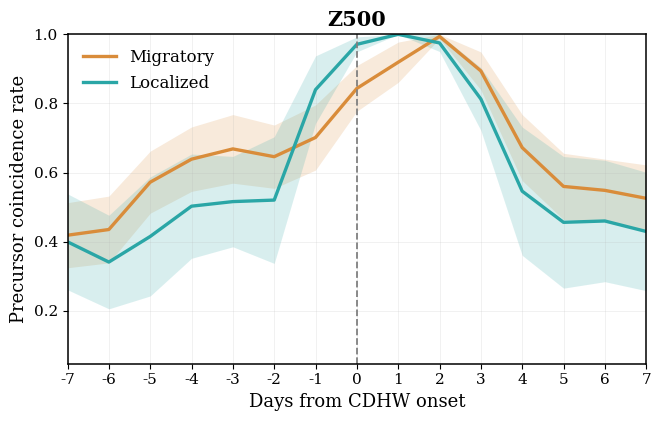


Saved figures for: Z500
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Z500_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Z500_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Z500_Migratory_Localized.tiff


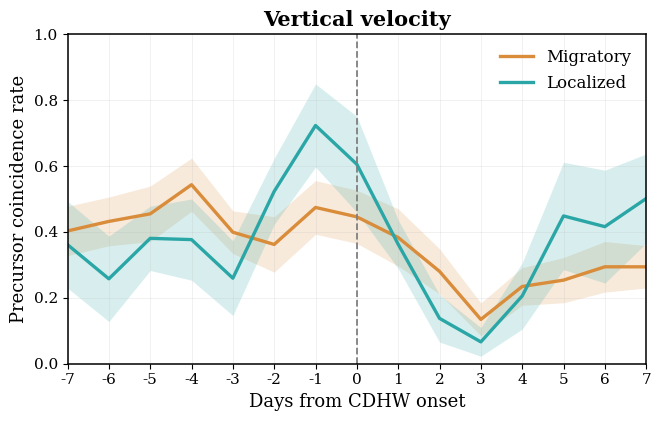


Saved figures for: Omega500
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Omega500_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Omega500_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Omega500_Migratory_Localized.tiff


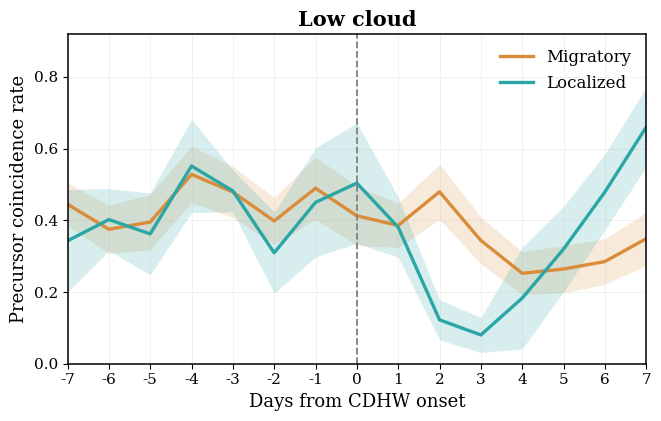


Saved figures for: Cloud_low
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Cloud_low_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Cloud_low_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Cloud_low_Migratory_Localized.tiff


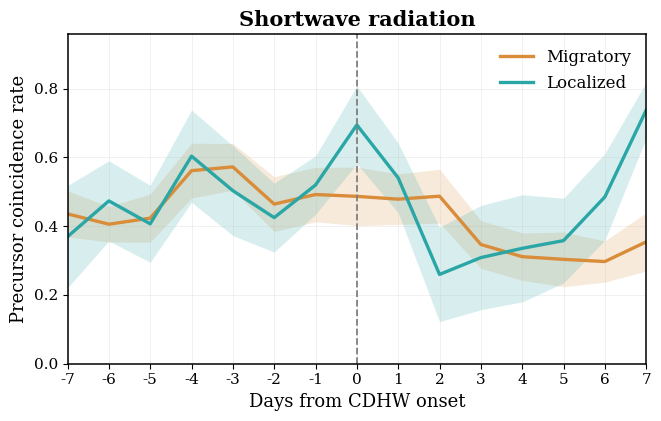


Saved figures for: NSWR_low
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_NSWR_low_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_NSWR_low_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_NSWR_low_Migratory_Localized.tiff


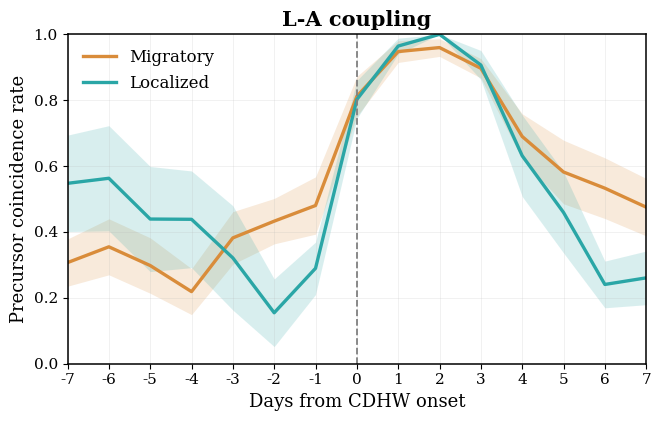


Saved figures for: Coupling
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Coupling_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Coupling_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_Coupling_Migratory_Localized.tiff


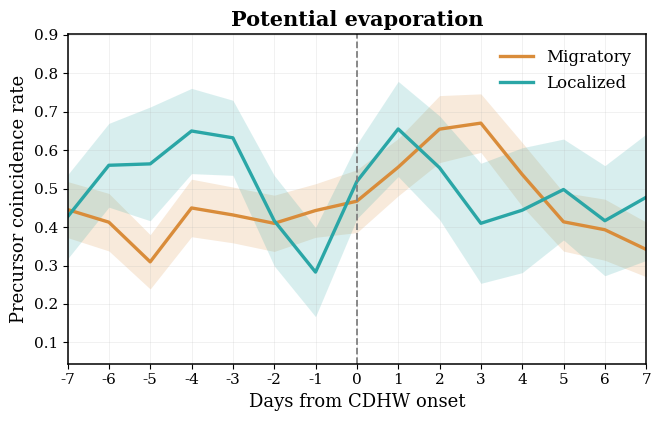


Saved figures for: PEVPR
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_PEVPR_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_PEVPR_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_PEVPR_Migratory_Localized.tiff


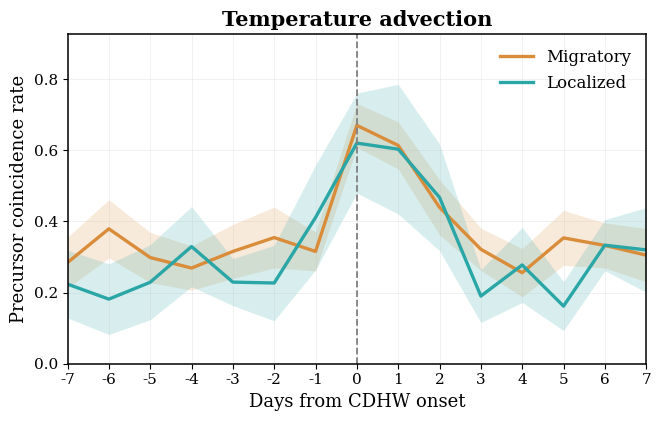


Saved figures for: T_adv
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_T_adv_Migratory_Localized.png
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_T_adv_Migratory_Localized.pdf
D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7\PCR_TwoLines_T_adv_Migratory_Localized.tiff

DONE: Saved 7 independent two-line plots.


In [3]:
# ================================================================
# INDEPENDENT PCR LINE PLOTS
#
# One separate plot for each variable
#
# Each plot:
#   x-axis  = Relative day from -7 to +7
#   lines   = Migratory and Localized in the same panel
#   shading = Mean ± SE across events
#
# Output:
#   7 independent figures
#
# Variables plotted:
#   1. Z500
#   2. Omega500
#   3. Cloud_low
#   4. NSWR_low
#   5. Coupling
#   6. PEVPR
#   7. T_adv
#
# Excluded:
#   T2M
#   VIMFD
#   LHTFL_low
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# USER PATHS
# ================================================================

event_pcr_csv = Path(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\LeadLag_LocalOnset_PCR_General_CDHW_Radius_Minus7_Plus7_All10\Event_Level_Local_Onset_PCR_General_CDHW_Radius_Minus7_Plus7_All10_NoBootstrap.csv"
)

cluster_file = Path(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\North_America\EventIDs_ByCluster_TwoColumns.xlsx"
)

output_dir = Path(
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data\Step-7_Mechanism\PCR_Independent_LinePlots_TwoLines_Migratory_Localized_All7"
)

output_dir.mkdir(parents=True, exist_ok=True)


# ================================================================
# SETTINGS
# ================================================================

x_min = -7
x_max = 7

relative_days = np.arange(x_min, x_max + 1, 1)

selected_vars = [
    "Z500",
    "Omega500",
    "Cloud_low",
    "NSWR_low",
    "Coupling",
    "PEVPR",
    "T_adv"
]

excluded_vars = [
    "T2M",
    "VIMFD",
    "LHTFL_low"
]

group_order = [
    "Migratory",
    "Localized"
]

label_map = {
    "Z500": "Z500",
    "Omega500": "Vertical velocity",
    "Cloud_low": "Low cloud",
    "NSWR_low": "Shortwave radiation",
    "Coupling": "L-A coupling",
    "PEVPR": "Potential evaporation",
    "T_adv": "Temperature advection"
}

color_map = {
    "Migratory": "#d98c3a",
    "Localized": "#2aa6a6"
}


# ================================================================
# HELPER FUNCTIONS
# ================================================================

def find_column(df, possible_names):
    clean_map = {}

    for col in df.columns:
        clean_col = str(col).lower().replace(" ", "").replace("_", "")
        clean_map[clean_col] = col

    for name in possible_names:
        clean_name = name.lower().replace(" ", "").replace("_", "")

        if clean_name in clean_map:
            return clean_map[clean_name]

    raise ValueError(
        f"Could not find any of these columns: {possible_names}\n"
        f"Available columns: {df.columns.tolist()}"
    )


def read_cluster_event_ids(cluster_file):
    df = pd.read_excel(cluster_file)

    cluster0_col = find_column(
        df,
        ["cluster_0", "cluster0", "Cluster 0", "Cluster_0"]
    )

    cluster1_col = find_column(
        df,
        ["cluster_1", "cluster1", "Cluster 1", "Cluster_1"]
    )

    cluster0_ids = (
        pd.to_numeric(df[cluster0_col], errors="coerce")
        .dropna()
        .astype(int)
        .drop_duplicates()
    )

    cluster1_ids = (
        pd.to_numeric(df[cluster1_col], errors="coerce")
        .dropna()
        .astype(int)
        .drop_duplicates()
    )

    migratory_df = pd.DataFrame(
        {
            "Event_ID": cluster0_ids.values,
            "Group": "Migratory"
        }
    )

    localized_df = pd.DataFrame(
        {
            "Event_ID": cluster1_ids.values,
            "Group": "Localized"
        }
    )

    group_df = pd.concat(
        [
            migratory_df,
            localized_df
        ],
        ignore_index=True
    )

    return group_df, cluster0_ids.values, cluster1_ids.values


# ================================================================
# READ EVENT-LEVEL PCR FILE
# ================================================================

print("\nReading event-level PCR file:")
print(event_pcr_csv)

if not event_pcr_csv.exists():
    raise FileNotFoundError(
        f"Could not find event-level PCR file:\n{event_pcr_csv}"
    )

pcr_df = pd.read_csv(event_pcr_csv)

pcr_df.columns = pcr_df.columns.str.strip()

required_cols = [
    "Event_ID",
    "Variable",
    "Relative_Day",
    "PCR_Event"
]

for c in required_cols:
    if c not in pcr_df.columns:
        raise ValueError(
            f"Missing required column: {c}\n"
            f"Available columns: {pcr_df.columns.tolist()}"
        )

pcr_df["Event_ID"] = pd.to_numeric(
    pcr_df["Event_ID"],
    errors="coerce"
).astype("Int64")

pcr_df["Relative_Day"] = pd.to_numeric(
    pcr_df["Relative_Day"],
    errors="coerce"
).astype("Int64")

pcr_df["PCR_Event"] = pd.to_numeric(
    pcr_df["PCR_Event"],
    errors="coerce"
)

pcr_df = pcr_df.dropna(
    subset=[
        "Event_ID",
        "Variable",
        "Relative_Day",
        "PCR_Event"
    ]
).copy()

pcr_df["Event_ID"] = pcr_df["Event_ID"].astype(int)
pcr_df["Relative_Day"] = pcr_df["Relative_Day"].astype(int)


# ================================================================
# READ CLUSTER EVENT-ID FILE
# ================================================================

print("\nReading cluster event-ID file:")
print(cluster_file)

if not cluster_file.exists():
    raise FileNotFoundError(
        f"Could not find cluster file:\n{cluster_file}"
    )

group_df, cluster0_ids, cluster1_ids = read_cluster_event_ids(
    cluster_file
)


# ================================================================
# ADD GROUP LABELS TO PCR DATA
# ================================================================

pcr_df = pcr_df.merge(
    group_df,
    on="Event_ID",
    how="inner"
)

# ================================================================
# FILTER TO 7 VARIABLES AND DAYS -7 TO +7
# ================================================================

pcr_df = pcr_df[
    pcr_df["Variable"].isin(selected_vars)
].copy()

pcr_df = pcr_df[
    (pcr_df["Relative_Day"] >= x_min)
    & (pcr_df["Relative_Day"] <= x_max)
].copy()

available_vars = sorted(
    pcr_df["Variable"].dropna().unique()
)

missing_vars = sorted(
    set(selected_vars) - set(available_vars)
)

if len(missing_vars) > 0:
    raise ValueError(
        "These selected variables are missing from the event-level PCR file:\n"
        + "\n".join(missing_vars)
    )


# ================================================================
# SUMMARY ACROSS EVENTS
#
# For each:
#   Group × Variable × Relative_Day
#
# Calculate:
#   Mean PCR
#   SE across events
# ================================================================

summary_df = (
    pcr_df
    .groupby(
        [
            "Group",
            "Variable",
            "Relative_Day"
        ],
        as_index=False
    )
    .agg(
        N_Events=("PCR_Event", "count"),
        Mean_PCR=("PCR_Event", "mean"),
        Std_PCR=("PCR_Event", "std")
    )
)

summary_df["SE_PCR"] = (
    summary_df["Std_PCR"]
    / np.sqrt(summary_df["N_Events"])
)

summary_df["Lower"] = (
    summary_df["Mean_PCR"]
    - summary_df["SE_PCR"]
).clip(lower=0, upper=1)

summary_df["Upper"] = (
    summary_df["Mean_PCR"]
    + summary_df["SE_PCR"]
).clip(lower=0, upper=1)

summary_csv = output_dir / "Summary_PCR_Independent_TwoLinePlots_All7.csv"

summary_df.to_csv(
    summary_csv,
    index=False
)


# ================================================================
# VARIABLE-SPECIFIC Y-LIMITS
#
# Each variable gets its own y-axis range.
# The same y-axis range is used for Migratory and Localized
# because both lines are in the same plot.
# ================================================================

ylimit_dict = {}

for var in selected_vars:

    dd_var = summary_df[
        summary_df["Variable"] == var
    ].copy()

    y_min_data = dd_var["Lower"].min()
    y_max_data = dd_var["Upper"].max()

    y_range = y_max_data - y_min_data

    if y_range == 0 or np.isnan(y_range):
        y_range = 0.05

    pad = 0.20 * y_range

    y_lower = y_min_data - pad
    y_upper = y_max_data + pad

    y_lower = max(0, y_lower)
    y_upper = min(1, y_upper)

    if (y_upper - y_lower) < 0.08:
        center = (y_upper + y_lower) / 2
        y_lower = max(0, center - 0.04)
        y_upper = min(1, center + 0.04)

    ylimit_dict[var] = (y_lower, y_upper)


# ================================================================
# MAKE 7 INDEPENDENT TWO-LINE PLOTS
# ================================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 13

for var in selected_vars:

    fig, ax = plt.subplots(
        figsize=(6.8, 4.4)
    )

    for group_name in group_order:

        dd = summary_df[
            (summary_df["Variable"] == var)
            & (summary_df["Group"] == group_name)
        ].copy()

        dd = dd.set_index("Relative_Day").reindex(relative_days)

        x = relative_days
        y = dd["Mean_PCR"].values
        y_low = dd["Lower"].values
        y_high = dd["Upper"].values

        color = color_map[group_name]

        ax.plot(
            x,
            y,
            color=color,
            linewidth=2.4,
            label=group_name
        )

        ax.fill_between(
            x,
            y_low,
            y_high,
            color=color,
            alpha=0.18,
            linewidth=0
        )

    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1.3
    )

    ax.grid(
        True,
        axis="both",
        alpha=0.20,
        linewidth=0.6
    )

    ax.set_xlim(
        x_min,
        x_max
    )

    ax.set_ylim(
        ylimit_dict[var]
    )

    ax.set_xticks(
        np.arange(x_min, x_max + 1, 1)
    )

    ax.set_xticklabels(
        np.arange(x_min, x_max + 1, 1),
        fontsize=11
    )

    ax.set_xlabel(
        "Days from CDHW onset",
        fontsize=13
    )

    ax.set_ylabel(
        "Precursor coincidence rate",
        fontsize=13
    )

    ax.set_title(
        label_map[var],
        fontsize=15,
        fontweight="bold"
    )

    ax.legend(
        frameon=False,
        fontsize=12,
        loc="best"
    )

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

    plt.tight_layout()

    safe_var = (
        var.replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    fig_png = output_dir / f"PCR_TwoLines_{safe_var}_Migratory_Localized.png"
    fig_pdf = output_dir / f"PCR_TwoLines_{safe_var}_Migratory_Localized.pdf"
    fig_tiff = output_dir / f"PCR_TwoLines_{safe_var}_Migratory_Localized.tiff"

    plt.savefig(
        fig_png,
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        fig_pdf,
        bbox_inches="tight"
    )

    plt.savefig(
        fig_tiff,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print("\nSaved figures for:", var)
    print(fig_png)
    print(fig_pdf)
    print(fig_tiff)


print("\nDONE: Saved 7 independent two-line plots.")

C:\Users\Amitesh\AppData\Local\Temp\ipykernel_34676\505971758.py:87: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Migratory' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[


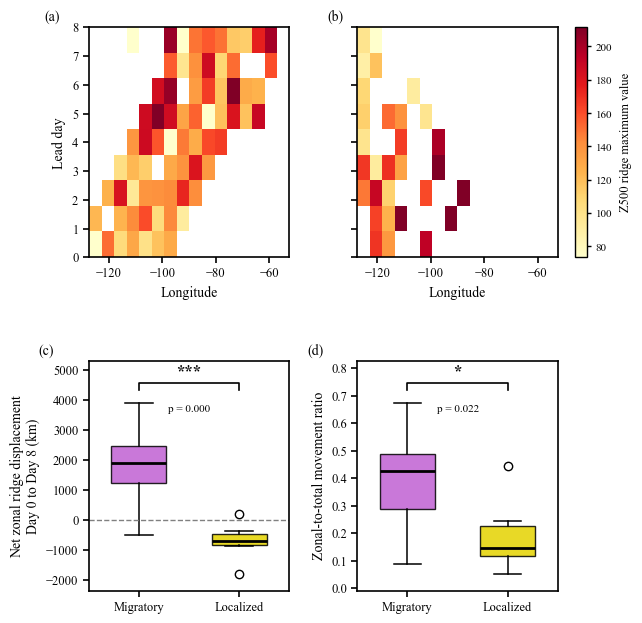

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 4,
    "ytick.major.size": 4
})


# ============================================================
# INPUT FILES
# ============================================================

trajectory_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America"
    r"\Z500_max_trajectory_Cluster1_SE_in_USA_10days.xlsx"
)

cluster_file = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Processing\Processed Data"
    r"\Step-7_Mechanism\North_America"
    r"\EventIDs_ByCluster_TwoColumns.xlsx"
)

out_dir = (
    r"D:\PhD_Research\Paper-3_CHDW_Migration\Results"
    r"\Ridge_Propagation_Combined_Figure"
)

os.makedirs(out_dir, exist_ok=True)


# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(trajectory_file)
cluster_df = pd.read_excel(cluster_file)

df.columns = df.columns.str.strip()
cluster_df.columns = cluster_df.columns.str.strip()

df = df[df["lead_day"].between(0, 8)].copy()
df = df.sort_values(["event_id", "lead_day"])


# ============================================================
# GROUP EVENT IDS
# First column  = Migratory
# Second column = Localized
# ============================================================

migratory_ids = (
    cluster_df.iloc[:, 0]
    .dropna()
    .astype(int)
    .unique()
)

localized_ids = (
    cluster_df.iloc[:, 1]
    .dropna()
    .astype(int)
    .unique()
)

df["Group"] = np.nan

df.loc[
    df["event_id"].isin(migratory_ids),
    "Group"
] = "Migratory"

df.loc[
    df["event_id"].isin(localized_ids),
    "Group"
] = "Localized"

df = df.dropna(subset=["Group"]).copy()


# ============================================================
# FUNCTIONS
# ============================================================

def lon_to_180(lon):

    lon = float(lon)

    if lon > 180:
        lon -= 360

    return lon


def haversine(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def p_stars(p):

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return "ns"


# ============================================================
# CONVERT LONGITUDE
# ============================================================

df["lon180"] = df["z500_max_lon"].apply(lon_to_180)


# ============================================================
# HOVMOLLER SETTINGS
# ============================================================

lon_min = -130
lon_max = -50
bin_width = 5

lon_bins = np.arange(
    lon_min,
    lon_max + bin_width,
    bin_width
)

lon_centers = (
    lon_bins[:-1] + lon_bins[1:]
) / 2


# ============================================================
# HOVMOLLER FUNCTION
# ============================================================

def make_hovmoller(group_df):

    lead_days = np.arange(0, 9)

    hov = np.full(
        (
            len(lead_days),
            len(lon_centers)
        ),
        np.nan
    )

    for i, day in enumerate(lead_days):

        day_df = group_df[
            group_df["lead_day"] == day
        ].copy()

        if day_df.empty:
            continue

        day_df["lon_bin"] = pd.cut(
            day_df["lon180"],
            bins=lon_bins,
            labels=lon_centers,
            include_lowest=True
        )

        grouped = (
            day_df.groupby(
                "lon_bin",
                observed=False
            )["z500_max_value"]
            .mean()
        )

        for j, lon_c in enumerate(lon_centers):

            if lon_c in grouped.index:
                hov[i, j] = grouped.loc[lon_c]

    return hov


# ============================================================
# CREATE HOVMOLLER MATRICES
# ============================================================

hov_migratory = make_hovmoller(
    df[df["Group"] == "Migratory"]
)

hov_localized = make_hovmoller(
    df[df["Group"] == "Localized"]
)


# ============================================================
# COMMON COLOR SCALE
# ============================================================

all_vals = np.concatenate([
    hov_migratory[np.isfinite(hov_migratory)],
    hov_localized[np.isfinite(hov_localized)]
])

vmin = np.nanpercentile(
    all_vals,
    5
)

vmax = np.nanpercentile(
    all_vals,
    95
)


# ============================================================
# EVENTWISE METRICS
# ============================================================

results = []

for event_id, sub in df.groupby("event_id"):

    sub = sub.sort_values("lead_day")

    if (
        0 not in sub["lead_day"].values
        or
        8 not in sub["lead_day"].values
    ):
        continue

    row0 = (
        sub[
            sub["lead_day"] == 0
        ]
        .iloc[0]
    )

    row8 = (
        sub[
            sub["lead_day"] == 8
        ]
        .iloc[0]
    )

    lats = sub["z500_max_lat"].values
    lons = sub["lon180"].values

    total_path = 0.0

    for i in range(len(sub) - 1):

        total_path += haversine(
            lats[i],
            lons[i],
            lats[i + 1],
            lons[i + 1]
        )

    lon0 = row0["lon180"]
    lon8 = row8["lon180"]

    lat_mean = np.nanmean([
        row0["z500_max_lat"],
        row8["z500_max_lat"]
    ])

    net_zonal_km = (
        (lon8 - lon0)
        * 111.32
        * np.cos(
            np.radians(lat_mean)
        )
    )

    if total_path > 0:

        zonal_ratio = (
            abs(net_zonal_km)
            / total_path
        )

    else:

        zonal_ratio = np.nan

    results.append({
        "event_id":
            event_id,

        "Group":
            row0["Group"],

        "total_path_km":
            total_path,

        "net_zonal_displacement_km":
            net_zonal_km,

        "zonal_to_total_ratio":
            zonal_ratio
    })


# ============================================================
# METRICS DATAFRAME
# ============================================================

metrics_df = pd.DataFrame(results)


# ============================================================
# SAVE METRICS
# ============================================================

metrics_out = os.path.join(
    out_dir,
    "Z500_Ridge_Propagation_Metrics.xlsx"
)

metrics_df.to_excel(
    metrics_out,
    index=False
)


# ============================================================
# DATA FOR BOXPLOTS
# ============================================================

mig_zonal = metrics_df[
    metrics_df["Group"] == "Migratory"
]["net_zonal_displacement_km"].dropna()

loc_zonal = metrics_df[
    metrics_df["Group"] == "Localized"
]["net_zonal_displacement_km"].dropna()


mig_ratio = metrics_df[
    metrics_df["Group"] == "Migratory"
]["zonal_to_total_ratio"].dropna()

loc_ratio = metrics_df[
    metrics_df["Group"] == "Localized"
]["zonal_to_total_ratio"].dropna()


# ============================================================
# MANN-WHITNEY U TEST
# ============================================================

_, p_zonal = mannwhitneyu(
    mig_zonal,
    loc_zonal,
    alternative="two-sided"
)

_, p_ratio = mannwhitneyu(
    mig_ratio,
    loc_ratio,
    alternative="two-sided"
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.7, 6.4)
)

ax1, ax2, ax3, ax4 = axes.flatten()


# ============================================================
# (a) MIGRATORY HOVMOLLER
# ============================================================

im1 = ax1.imshow(
    hov_migratory,
    aspect="auto",
    origin="lower",
    extent=[
        lon_centers[0],
        lon_centers[-1],
        0,
        8
    ],
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

ax1.set_xlabel(
    "Longitude"
)

ax1.set_ylabel(
    "Lead day"
)

ax1.set_yticks(
    np.arange(0, 9, 1)
)

ax1.set_xticks(
    [-120, -100, -80, -60]
)

ax1.text(
    -0.22,
    1.03,
    "(a)",
    transform=ax1.transAxes,
    fontsize=10
)


# ============================================================
# (b) LOCALIZED HOVMOLLER
# ============================================================

im2 = ax2.imshow(
    hov_localized,
    aspect="auto",
    origin="lower",
    extent=[
        lon_centers[0],
        lon_centers[-1],
        0,
        8
    ],
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

ax2.set_xlabel(
    "Longitude"
)

ax2.set_yticks(
    np.arange(0, 9, 1)
)

ax2.set_yticklabels([])

ax2.set_xticks(
    [-120, -100, -80, -60]
)

ax2.text(
    -0.15,
    1.03,
    "(b)",
    transform=ax2.transAxes,
    fontsize=10
)


# ============================================================
# BOXPLOT FUNCTION
# ============================================================

def draw_boxplot(
    ax,
    data1,
    data2,
    ylabel,
    pvalue,
    panel_label,
    ylim_zero=False
):

    box = ax.boxplot(
        [
            data1,
            data2
        ],
        patch_artist=True,
        widths=0.55,
        showfliers=True
    )

    colors = [
        "#C060D3",
        "#E5D300"
    ]

    for patch, color in zip(
        box["boxes"],
        colors
    ):

        patch.set_facecolor(
            color
        )

        patch.set_alpha(
            0.85
        )

    for median in box["medians"]:

        median.set_color(
            "black"
        )

        median.set_linewidth(
            2.0
        )

    for whisker in box["whiskers"]:
        whisker.set_linewidth(1.1)

    for cap in box["caps"]:
        cap.set_linewidth(1.1)

    ax.set_xticks(
        [1, 2]
    )

    ax.set_xticklabels(
        [
            "Migratory",
            "Localized"
        ]
    )

    ax.set_ylabel(
        ylabel
    )

    if ylim_zero:

        ax.axhline(
            0,
            color="gray",
            linewidth=1.0,
            linestyle="--"
        )

    ymax = max(
        np.nanmax(data1),
        np.nanmax(data2)
    )

    ymin = min(
        np.nanmin(data1),
        np.nanmin(data2)
    )

    yrange = ymax - ymin

    if yrange == 0:
        yrange = 1.0

    bar_y = (
        ymax
        + 0.08 * yrange
    )

    bar_h = (
        0.04 * yrange
    )

    ax.plot(
        [1, 1, 2, 2],
        [
            bar_y,
            bar_y + bar_h,
            bar_y + bar_h,
            bar_y
        ],
        lw=1.2,
        color="black"
    )

    ax.text(
        1.5,
        bar_y + bar_h + 0.02 * yrange,
        p_stars(pvalue),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        1.5,
        bar_y - 0.08 * yrange,
        f"p = {pvalue:.3f}",
        ha="center",
        va="top",
        fontsize=8
    )

    ax.set_ylim(
        ymin - 0.10 * yrange,
        ymax + 0.25 * yrange
    )

    ax.text(
        -0.25,
        1.03,
        panel_label,
        transform=ax.transAxes,
        fontsize=10
    )


# ============================================================
# (c) NET ZONAL DISPLACEMENT
# ============================================================

draw_boxplot(
    ax3,
    mig_zonal,
    loc_zonal,
    "Net zonal ridge displacement\nDay 0 to Day 8 (km)",
    p_zonal,
    "(c)",
    ylim_zero=True
)


# ============================================================
# (d) ZONAL-TO-TOTAL MOVEMENT RATIO
# ============================================================

draw_boxplot(
    ax4,
    mig_ratio,
    loc_ratio,
    "Zonal-to-total movement ratio",
    p_ratio,
    "(d)",
    ylim_zero=False
)


# ============================================================
# STYLE ALL MAIN AXES
# ============================================================

for ax in [
    ax1,
    ax2,
    ax3,
    ax4
]:

    ax.tick_params(
        axis="both",
        labelsize=9,
        width=1.2,
        length=4
    )

    for spine in ax.spines.values():

        spine.set_linewidth(
            1.2
        )


# ============================================================
# MAIN LAYOUT
#
# IMPORTANT:
# right = 0.82 leaves dedicated space for colorbar.
# ============================================================

plt.subplots_adjust(
    left=0.12,
    right=0.82,
    top=0.97,
    bottom=0.09,
    wspace=0.34,
    hspace=0.45
)


# ============================================================
# COLORBAR
# Dedicated colorbar beside panel (b)
# ============================================================

pos2 = ax2.get_position()

cbar_ax = fig.add_axes([
    pos2.x1 + 0.025,   # left position
    pos2.y0,           # bottom aligned with panel b
    0.018,             # width
    pos2.height        # same height as panel b
])

cbar = fig.colorbar(
    im2,
    cax=cbar_ax
)

cbar.set_label(
    "Z500 ridge maximum value",
    fontsize=9,
    labelpad=6
)

cbar.ax.tick_params(
    labelsize=8,
    width=1.0,
    length=3
)

cbar.outline.set_linewidth(
    1.0
)


# ============================================================
# SAVE FIGURE
# ============================================================

fig_out = os.path.join(
    out_dir,
    "Z500_Ridge_Propagation_2x2_Figure.png"
)

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# SHOW IN JUPYTER
# ============================================================

plt.show()

plt.close(fig)
